In [1]:
import xarray as xr
import pandas as pd
import os
from matplotlib import pyplot as plt
import statsmodels.api as sm

In [2]:
dataset_u = xr.open_dataset("test_output.nc")
dataset_v = xr.open_dataset("test_output_v.nc")
dataset_msl = xr.open_dataset("test_output_msl.nc")
sd = xr.open_dataset('surge-days_day_ERA5_historical_195911-202302.nc')
cendering_hourly=xr.open_dataset('h320a.nc')
geting_hourly=xr.open_dataset('h326a.nc')
kuantan_hourly=xr.open_dataset('h322a.nc')
tioman_hourly = xr.open_dataset('h323a.nc')
jb_hourly = xr.open_dataset('h321a.nc')
sedili_hourly = xr.open_dataset('h324a.nc')
tp_hourly=xr.open_dataset('h699a.nc')

In [3]:
months={1:31, 2:28, 3:31, 4:30, 5:31, 6:30, 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}
def testing_loop_idea(data, start, end):
    test_list=[]
    date_list=[]
    for year in range(start, end): 
        for i in range(1, 13):
            for j in range(1, months[i]+1):
                data_to_test = data.sel(time=slice(f"{year}-{i}-{j}T00:00:00.000000000", f"{year}-{i}-{j}T22:59:59.971200000"))
                nan_per=(data_to_test['sea_level'].size-int(data_to_test['sea_level'].count()))/data_to_test['sea_level'].size*100
                if nan_per<5:
                    test_list.append(data_to_test['sea_level'].max())
                    date_list.append(f"{year}-{i}-{j}")
    date_list = pd.to_datetime(date_list, format='%Y-%m-%d')
    return test_list, date_list

<Figure size 1920x1440 with 0 Axes>

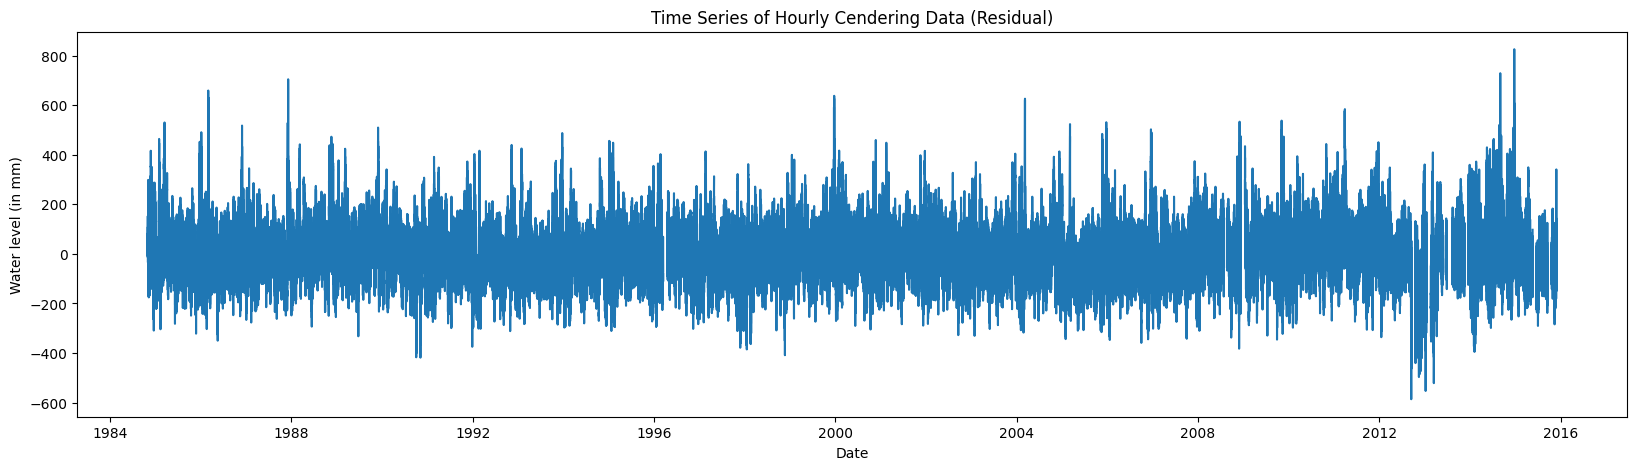

<Figure size 640x480 with 0 Axes>

In [4]:
cendering_dict = pd.DataFrame({'date' : list(cendering_hourly['time'].values), 'actual' : cendering_hourly['sea_level'].values[0]})
cendering_dict.to_csv("cendering_hourly.csv", index=False)
cendering_residual = pd.read_csv('Cendering_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(cendering_dict['date'][1:], cendering_residual[cendering_residual.columns[2]])
plt.title('Time Series of Hourly Cendering Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.show()
plt.savefig("Time Series of Hourly Cendering Data (Residual).png")

<Figure size 1920x1440 with 0 Axes>

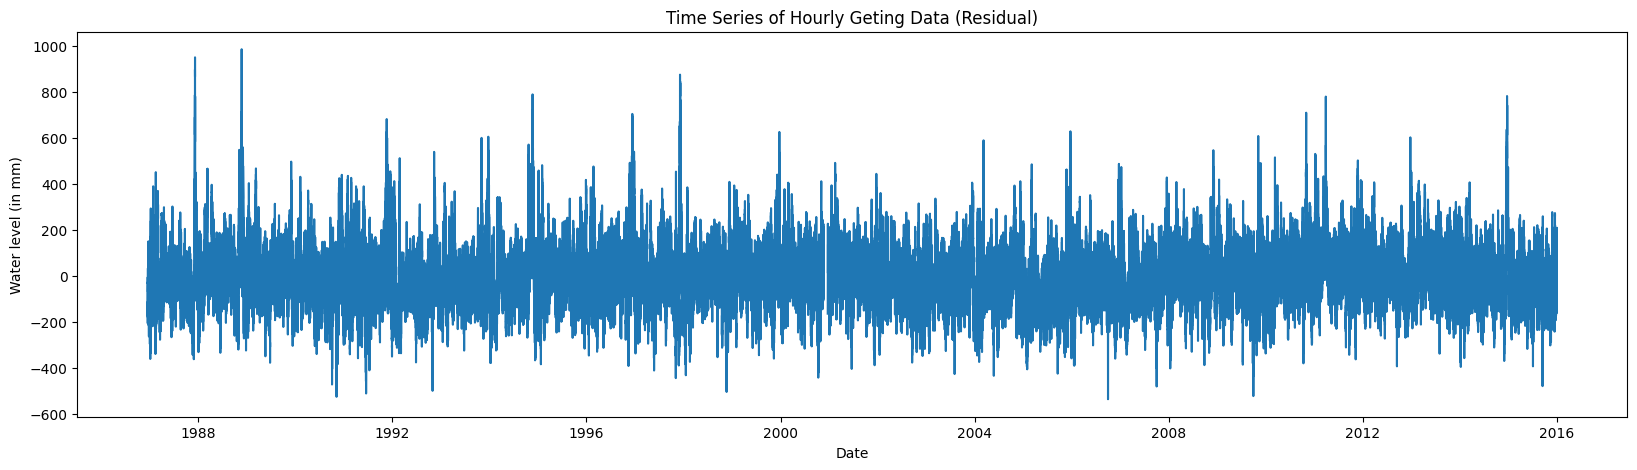

In [5]:
geting_dict = pd.DataFrame({'date' : list(geting_hourly['time'].values), 'actual' : geting_hourly['sea_level'].values[0]})
geting_residual = pd.read_csv('output_data_geting.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(geting_dict['date'][1:], geting_residual[geting_residual.columns[2]])
plt.title('Time Series of Hourly Geting Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Geting Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

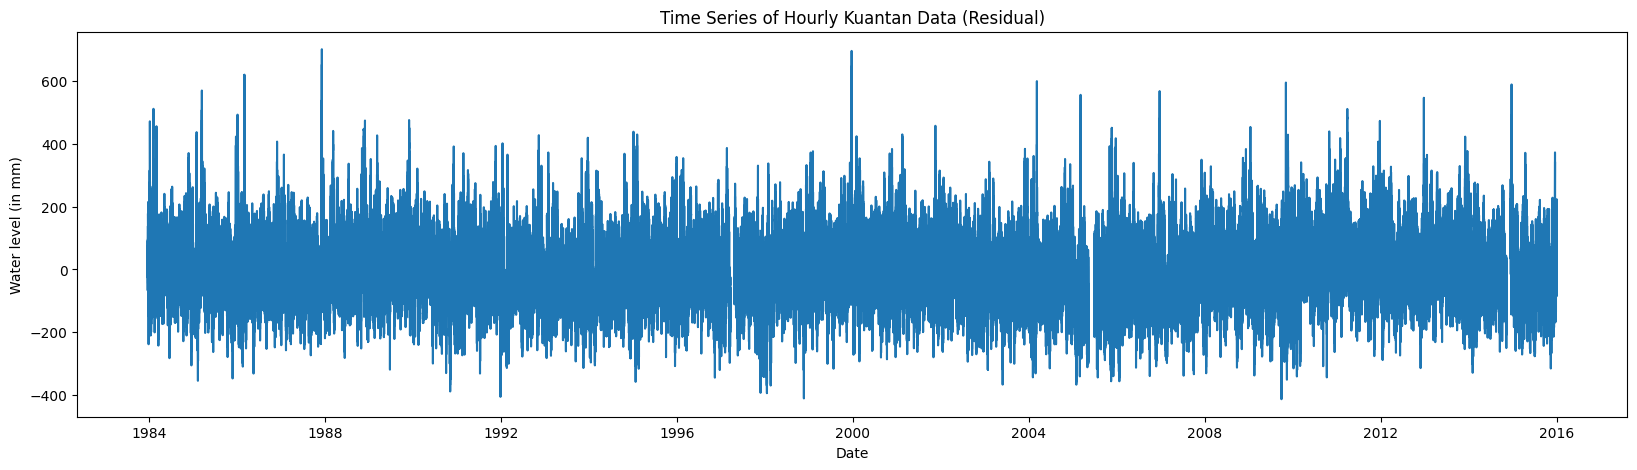

In [6]:
kuantan_dict = pd.DataFrame({'date' : list(kuantan_hourly['time'].values), 'actual' : kuantan_hourly['sea_level'].values[0]})
kuantan_residual = pd.read_csv('Kuantan_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(kuantan_dict['date'][1:], kuantan_residual[kuantan_residual.columns[2]])
plt.title('Time Series of Hourly Kuantan Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Kuantan Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

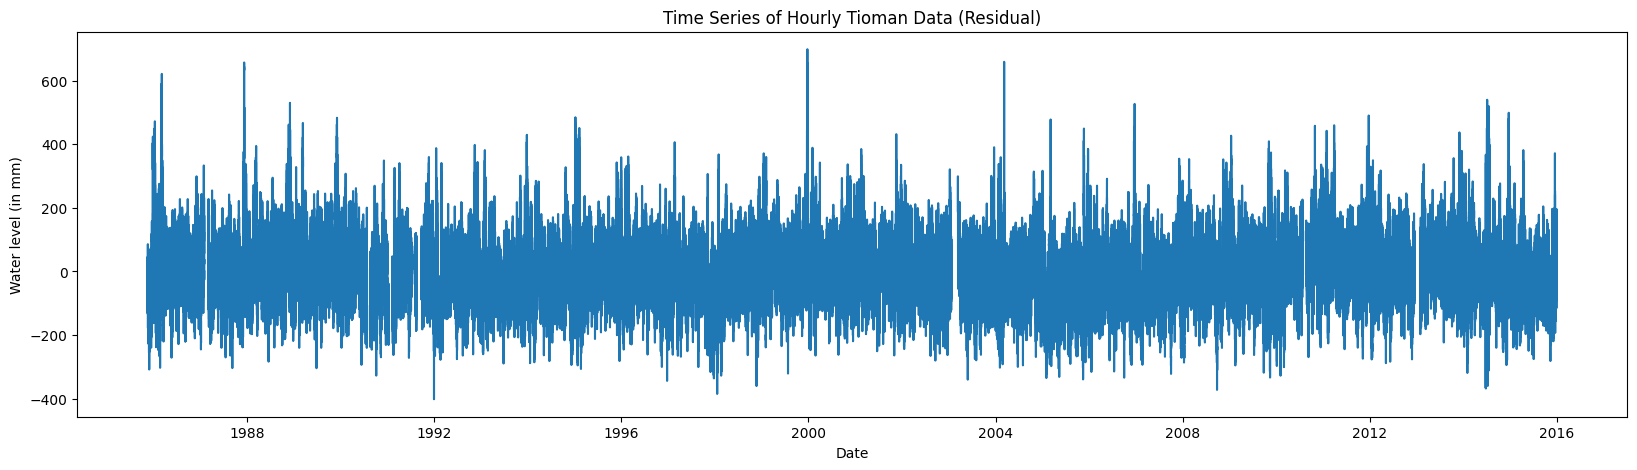

In [7]:
tioman_dict = pd.DataFrame({'date' : list(tioman_hourly['time'].values), 'actual' : tioman_hourly['sea_level'].values[0]})
tioman_residual = pd.read_csv('Tioman_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(tioman_dict['date'][1:], tioman_residual[tioman_residual.columns[2]])
plt.title('Time Series of Hourly Tioman Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Tioman Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

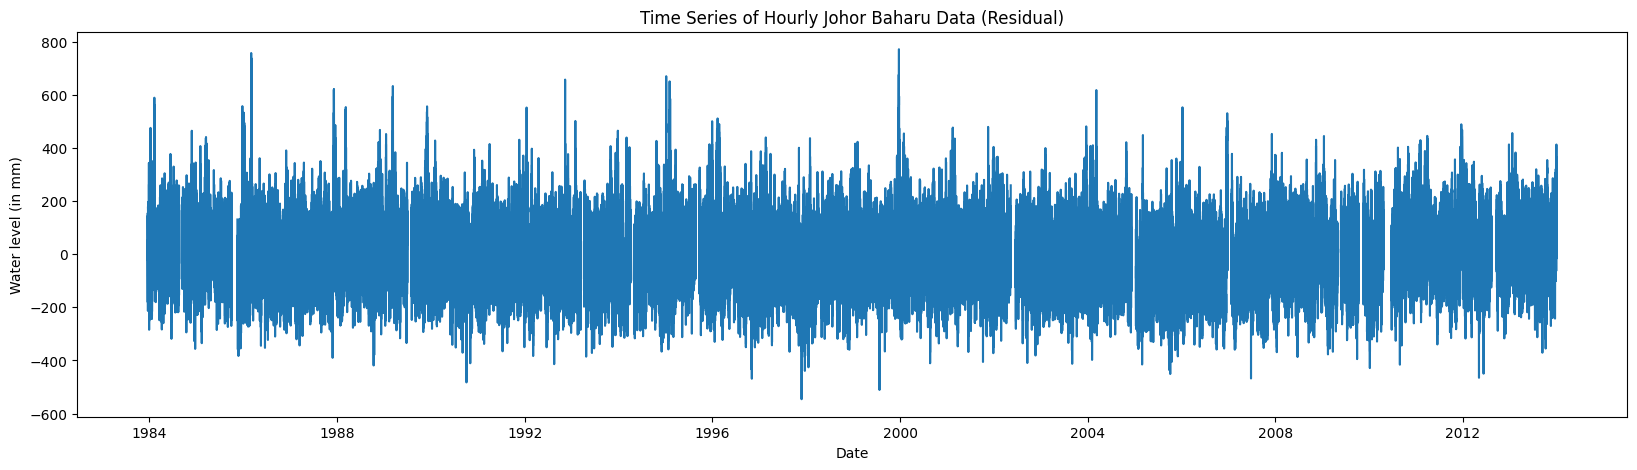

In [8]:
jb_dict = pd.DataFrame({'date' : list(jb_hourly['time'].values), 'actual' : jb_hourly['sea_level'].values[0]})
jb_residual = pd.read_csv('JB_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(jb_dict['date'][1:], jb_residual[jb_residual.columns[2]])
plt.title('Time Series of Hourly Johor Baharu Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Johor Baharu Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

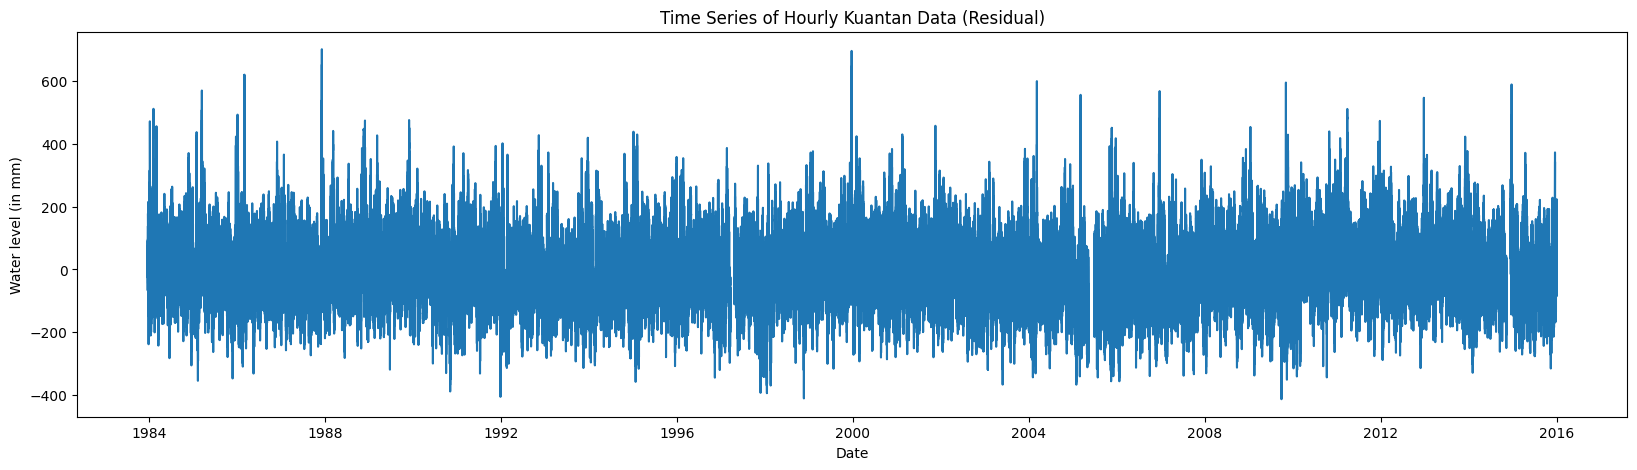

In [9]:
kuantan_dict = pd.DataFrame({'date' : list(kuantan_hourly['time'].values), 'actual' : kuantan_hourly['sea_level'].values[0]})
kuantan_residual = pd.read_csv('Kuantan_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(kuantan_dict['date'][1:], kuantan_residual[kuantan_residual.columns[2]])
plt.title('Time Series of Hourly Kuantan Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Kuantan Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

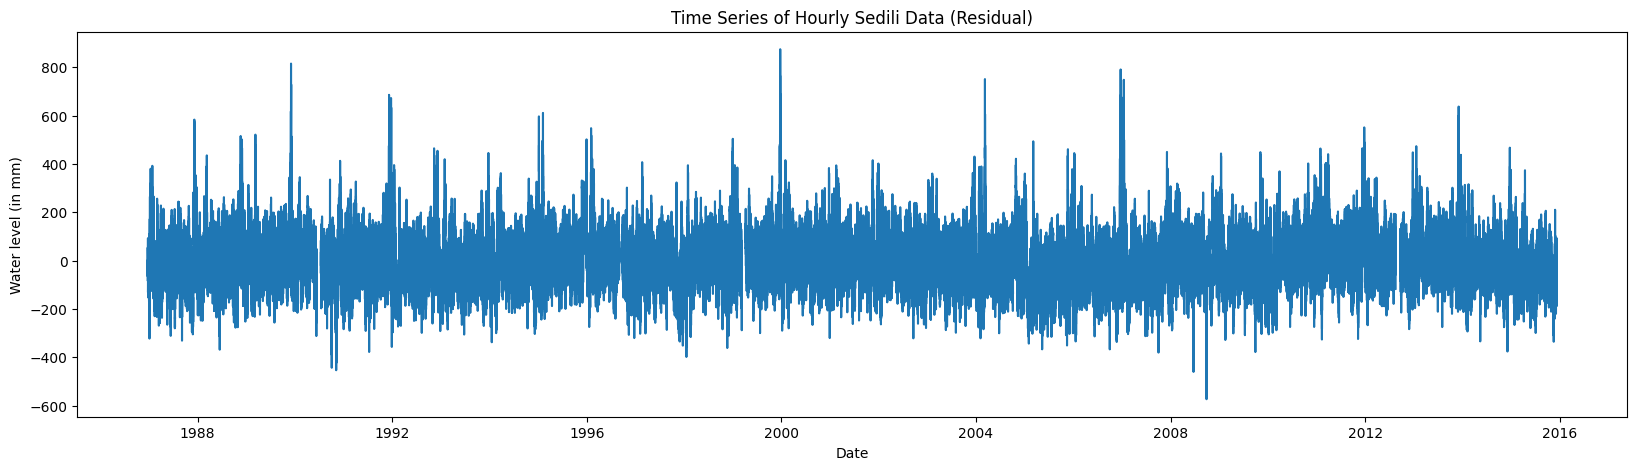

In [10]:
sedili_dict = pd.DataFrame({'date' : list(sedili_hourly['time'].values), 'actual' : sedili_hourly['sea_level'].values[0]})
sedili_residual = pd.read_csv('Sedili_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(sedili_dict['date'][1:], sedili_residual[sedili_residual.columns[2]])
plt.title('Time Series of Hourly Sedili Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Sedili Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

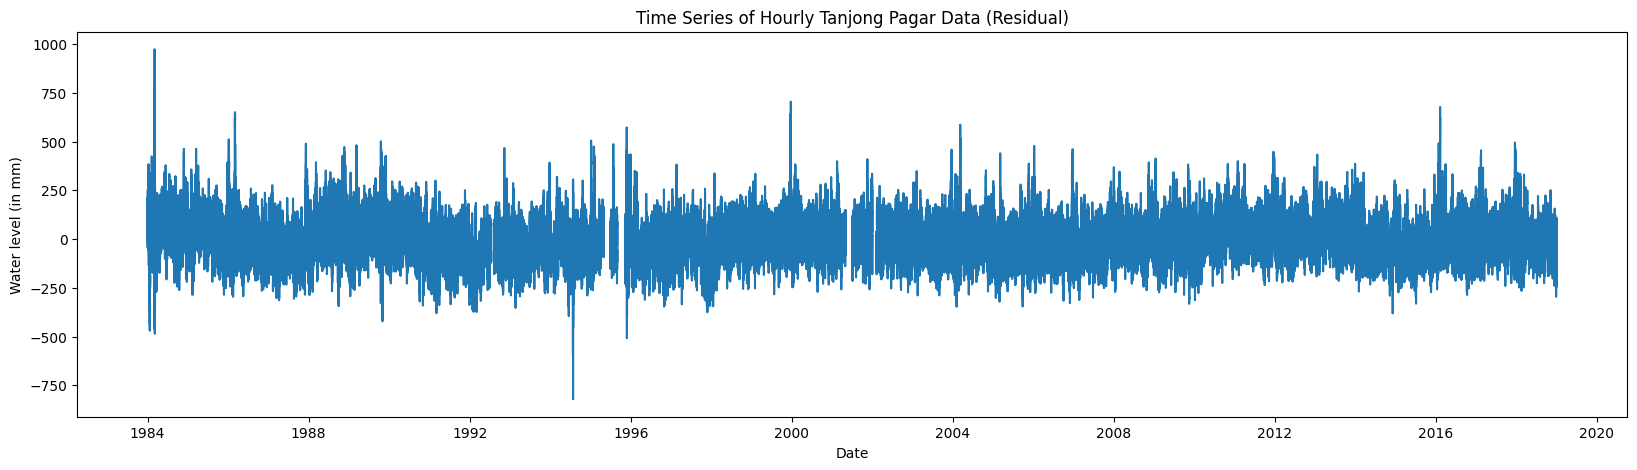

In [11]:
tp_dict = pd.DataFrame({'date' : list(tp_hourly['time'].values), 'actual' : tp_hourly['sea_level'].values[0]})
tp_residual = pd.read_csv('TP_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(tp_dict['date'][1:], tp_residual[tp_residual.columns[2]])
plt.title('Time Series of Hourly Tanjong Pagar Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Tanjong Pagar Data (Residual).png")
plt.show()

In [12]:
def make_plot(date, data, title):
    plt.figure(dpi=300)
    plt.subplots(figsize=(20, 5))
    plt.plot(date, data)
    plt.title(title)
    plt.ylabel('Water level (in mm)')
    plt.xlabel('Date')
    plt.savefig(f"{title}.png")
    plt.show()

In [13]:
time_coords = sd['time'].values
time_coords=pd.to_datetime(time_coords, format='%Y-%m-%d')
positive_surge_days=[]
values = sd['surge-day'].values
for time, value in zip(time_coords, values):
        if value==1.0:
            positive_surge_days.append(time)

In [14]:
dates = pd.to_datetime(geting_hourly['time'].values[1:])
dates = dates.floor('D')  # Round down to the nearest day

# Filter the index based on conditions
filtered_index = (dates.year >= 1990) & \
                 (dates.year <= 2011) & \
                 (dates.month.isin([11, 12, 1, 2])) & \
                 (dates.month != 2) & \
                 (dates.day != 29)

# Apply filtering to both dates and geting_residual
filtered_dates = dates[filtered_index]
filtered_residual = geting_residual[filtered_index]

# Group by date and find the maximum tide value
daily_max_tide = filtered_residual.groupby(filtered_dates).max()
daily_max_tide = daily_max_tide[daily_max_tide.columns[2]]

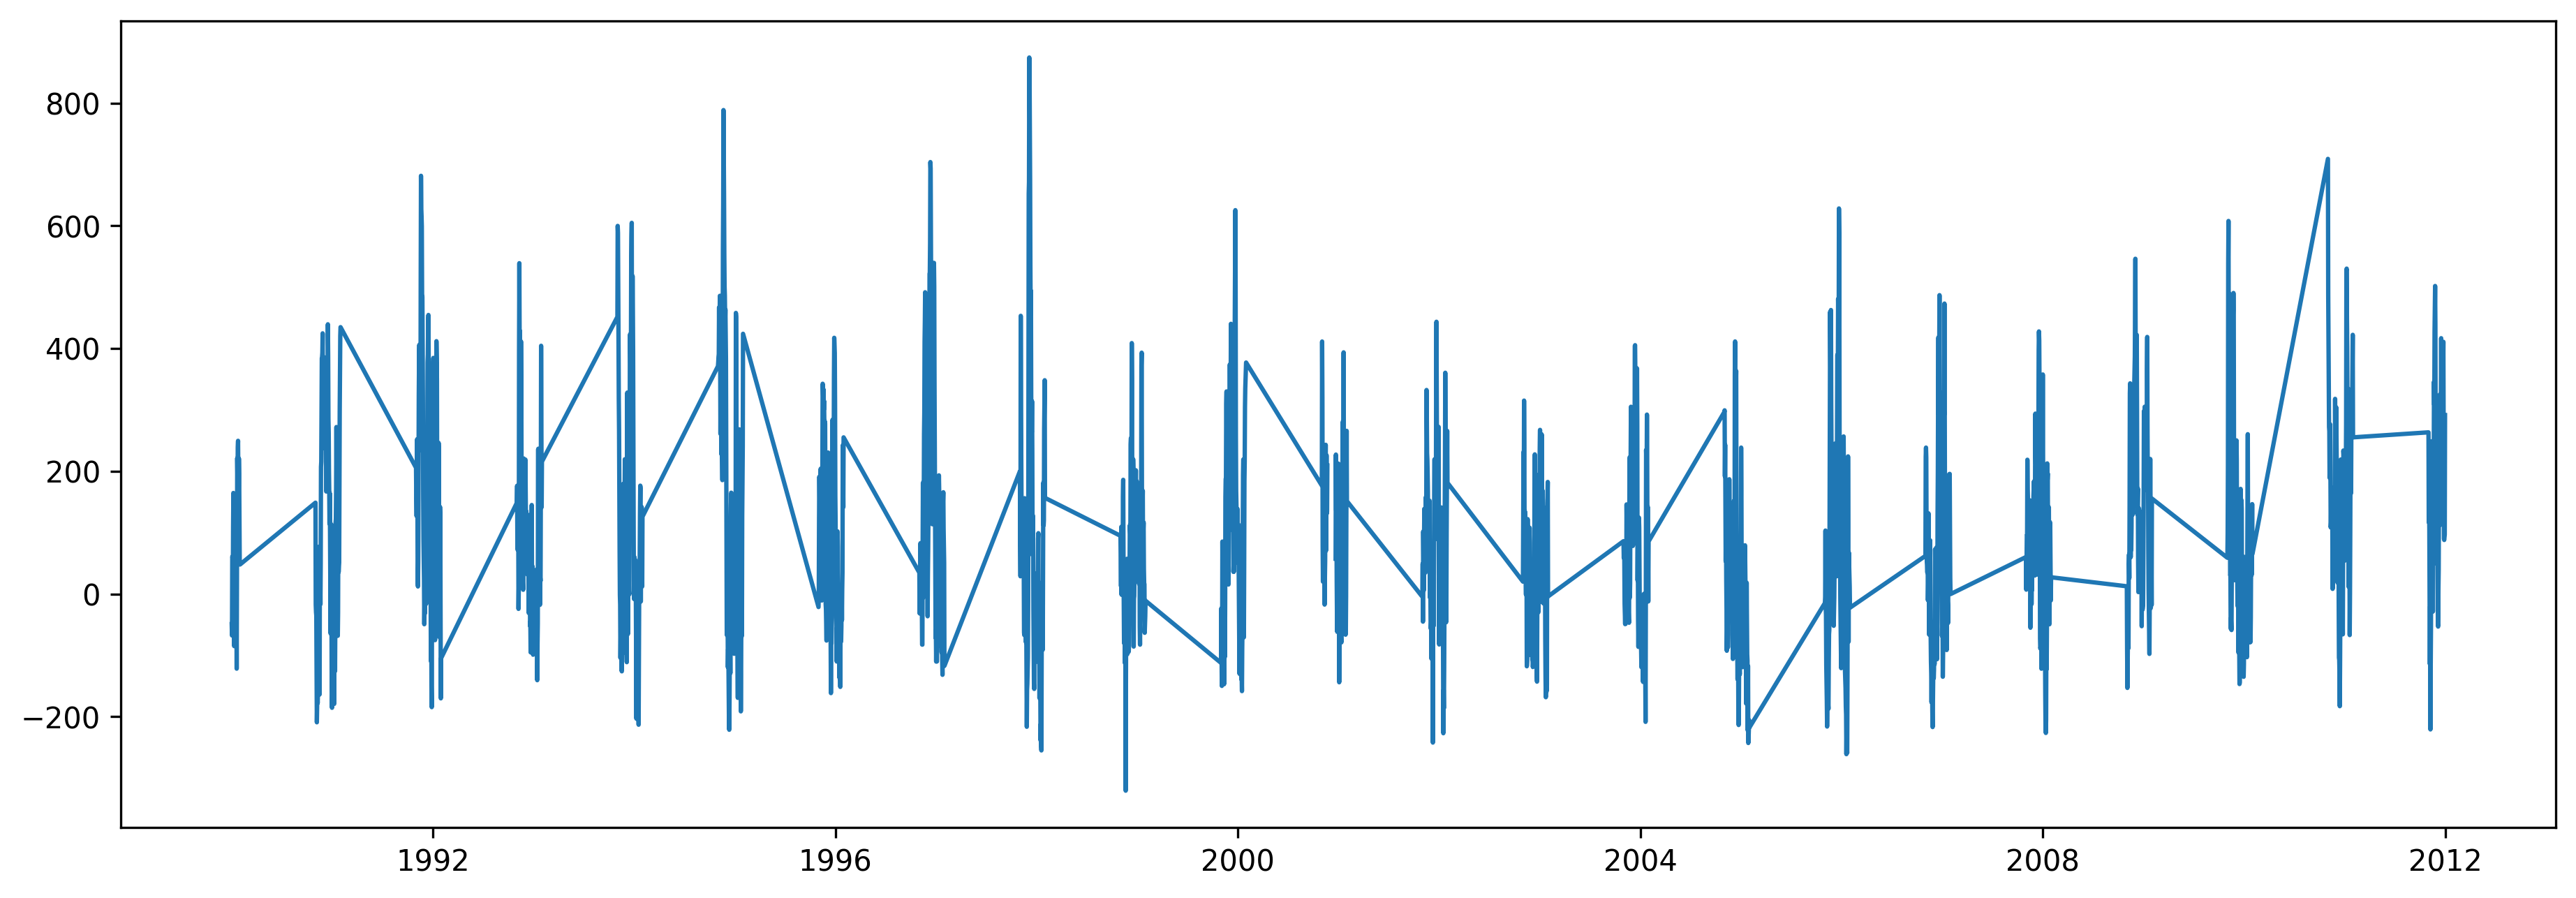

In [15]:
plt.figure(figsize=(15, 5), dpi=300)
plt.plot(daily_max_tide.index, daily_max_tide)

In [16]:
def max_cleaning(time, data) :
    dates = pd.to_datetime(time[1:])
    dates = dates.floor('D')  # Round down to the nearest day
    
    valid_index = data.notna().all(axis=1)  # Ensures rows have no NaN values
    dates = dates[valid_index]
    data = data[valid_index]

# Filter the index based on conditions
    filtered_index = (dates.year >= 1990) & \
                    (dates.year <= 2011) & \
                    (dates.month.isin([11, 12, 1, 2])) & \
                    (dates.month != 2) & \
                    (dates.day != 29)

# Apply filtering to both dates and geting_residual
    filtered_dates = dates[filtered_index]
    filtered_residual = data[filtered_index]

# Group by date and find the maximum tide value
    daily_max_tide = filtered_residual.groupby(filtered_dates).max()
    daily_max_tide = daily_max_tide[daily_max_tide.columns[2]]
    final_dates = daily_max_tide.index
    return daily_max_tide, final_dates

In [17]:
geting_residual_max,  dates_geting = max_cleaning(geting_hourly['time'].values, geting_residual)
tp_residual_max, dates_tp = max_cleaning(tp_hourly['time'].values, tp_residual)
cendering_residual_max, dates_cendering = max_cleaning(cendering_hourly['time'].values, cendering_residual)
kuantan_residual_max, dates_kuantan = max_cleaning(kuantan_hourly['time'].values, kuantan_residual)
sedili_residual_max, dates_sedili = max_cleaning(sedili_hourly['time'].values, sedili_residual)
tioman_residual_max, dates_tioman = max_cleaning(tioman_hourly['time'].values, tioman_residual)
jb_residual_max, dates_jb = max_cleaning(jb_hourly['time'].values, jb_residual)

<Figure size 1920x1440 with 0 Axes>

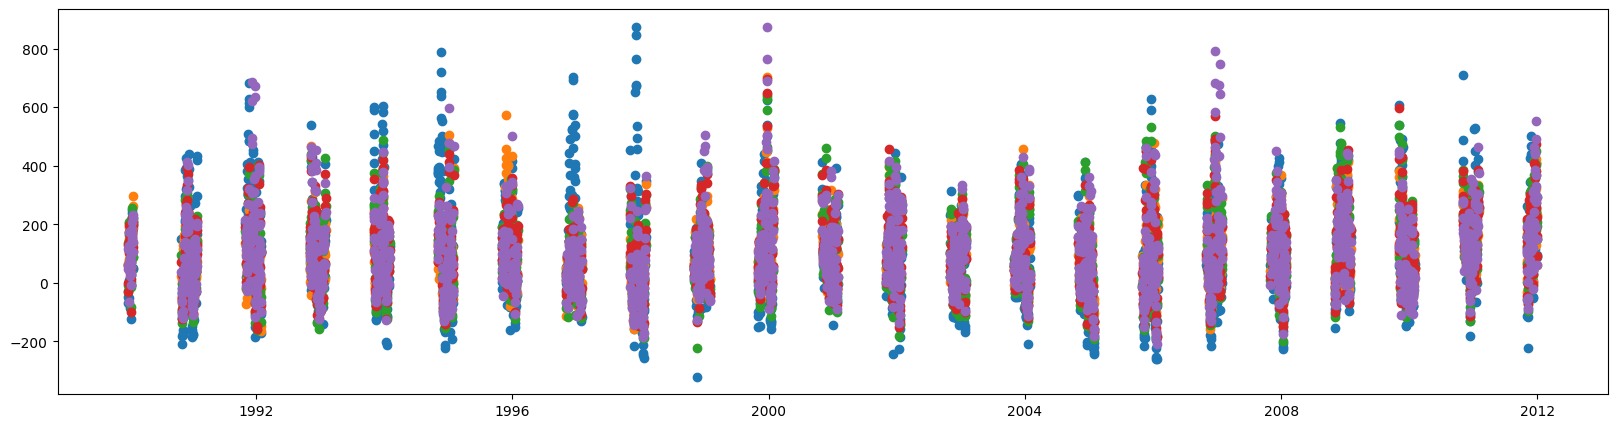

In [18]:
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.scatter(dates_geting, geting_residual_max)
plt.scatter(dates_tp, tp_residual_max)
plt.scatter(dates_cendering, cendering_residual_max)
plt.scatter(dates_kuantan, kuantan_residual_max)
plt.scatter(dates_sedili, sedili_residual_max)

plt.show()

In [19]:
def flatten_data(data, location, letter) :
    flattened_data = []
    for i in range(len(data['time'].values)):
        if data['time'].values[i] in location: 
            flattened_data.append(data[letter].values[i][0][0])
    return flattened_data

In [20]:
import math
def velocity(u_component, v_component):
    wind_test = []
    for i in range(len(v_component)) : 
        vel = math.sqrt(v_component[i]**2 + u_component[i]**2)
        wind_test.append(vel)
    return wind_test

In [21]:
#test for geting
u_component_geting = flatten_data(dataset_u, dates_geting, 'u')
v_component_geting = flatten_data(dataset_v, dates_geting, 'v')
msl_component_geting = flatten_data(dataset_msl, dates_geting, 'msl')
wind_component_geting = velocity(u_component_geting, v_component_geting)

In [22]:
import numpy as np
def plot_best_fit_line(residual, wind, title):
# Scatter plot
    plt.scatter(residual, wind, label="Data Points")

# Compute linear regression (best-fit line)
    slope, intercept = np.polyfit(residual, wind, 1)
    best_fit_line = slope * np.array(wind) + intercept

# Plot best-fit line
    plt.plot(geting_residual_max, best_fit_line, color='red', label=f'Best Fit Line (y = {slope:.2f}x + {intercept:.2f})')

# Labels and title
    plt.title('Wind vs. Residual Water Level')
    plt.xlabel('Water Level (mm)')
    plt.ylabel('Wind Speed (m/s)')
    plt.legend()
    plt.grid(True, alpha = 0.3)

# Show plot
    plt.show()

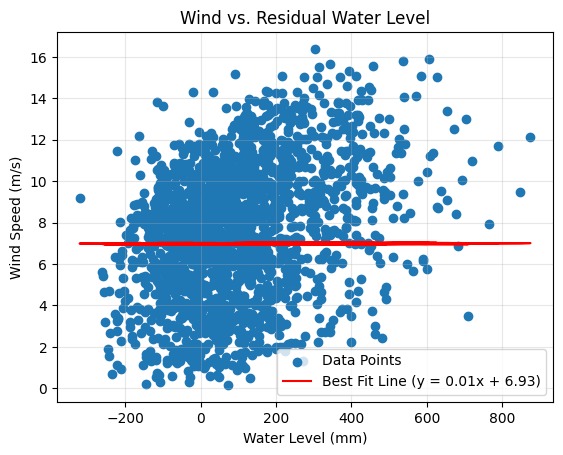

In [23]:
plot_best_fit_line(geting_residual_max, wind_component_geting, "Residual vs. Wind")

In [24]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [25]:
import seaborn as sns

In [26]:
def multi_linear_model(wind, msl, location):
    x_values = pd.DataFrame({'wind' : wind, 'msl':msl})
    y_values = location
   
    lm = LinearRegression()
    lm.fit(x_values, y_values)

# print intercept and coefficients
    print (lm.intercept_)
    print (lm.coef_)
    
    y_pred = lm.predict(x_values)

    # Compute R²
    r2 = r2_score(y_values, y_pred)
    print(f"R² Score: {r2:.3f}")
    
    mse = mean_squared_error(y_values, y_pred)
    rmse = mse ** 0.5  # Square root of MSE

    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")

In [27]:
# Scatter plot of residuals
    

In [28]:
multi_linear_model(wind_component_geting, msl_component_geting, geting_residual_max)

-15653.641735714926
[10.2475707  0.1541773]
R² Score: 0.180
MSE: 24960.039
RMSE: 157.987


In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def multi_non_linear_model(wind, msl, location, degree):
    # Prepare input features
    x_values = pd.DataFrame({'wind': wind, 'msl': msl})
    y_values = location
    
    # Create polynomial regression model pipeline
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    
    # Fit the model
    poly_model.fit(x_values, y_values)
    y_poly_pred = poly_model.predict(x_values)
    
    # Extract the LinearRegression model from the pipeline
    lin_reg = poly_model.named_steps['linearregression']
    
    # Print model coefficients
    print("Intercept:", lin_reg.intercept_)
    print("Coefficients:", lin_reg.coef_)
    
    # Evaluate the model
    r2_poly = r2_score(y_values, y_poly_pred)
    mse = mean_squared_error(y_values, y_poly_pred)
    rmse = np.sqrt(mse)  # Square root of MSE
    
    print(f"Polynomial (Degree {degree}) R²: {r2_poly:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")

    # 3D Scatter Plot + Regression Surface
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # Scatter plot of original data
    ax.scatter(wind, msl, location, color='red', label='Actual Data')

    # Create a mesh grid for plotting the polynomial surface
    wind_range = np.linspace(min(wind), max(wind), 30)
    msl_range = np.linspace(min(msl), max(msl), 30)
    wind_mesh, msl_mesh = np.meshgrid(wind_range, msl_range)
    
    # Convert meshgrid to input features
    X_mesh = pd.DataFrame({'wind': wind_mesh.ravel(), 'msl': msl_mesh.ravel()})
    y_mesh_pred = poly_model.predict(X_mesh)
    
    # Reshape predictions for surface plot
    y_mesh_pred = y_mesh_pred.reshape(wind_mesh.shape)
    
    # Plot the polynomial regression surface
    ax.plot_surface(wind_mesh, msl_mesh, y_mesh_pred, color='cyan', alpha=0.5, edgecolor='k')
    
        # Labels and title
    ax.set_xlabel('Wind Component', labelpad=10)
    ax.set_ylabel('MSL Component', labelpad=10)
    ax.set_zlabel('Residual', labelpad=10)
    ax.set_title('Linear Regression Fit', pad=20)
    ax.legend()

    # Adjust margins to avoid cut-off
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

    # Optional: use tight_layout (sometimes has limited effect in 3D)
    plt.tight_layout()

    plt.show()


# Example usage (assuming you have data)
# wind = np.array([...])
# msl = np.array([...])
# location = np.array([...])
# multi_non_linear_model(wind, msl, location, 2)


In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

In [32]:
def tree_regressor(wind, msl, location):
    x_values = pd.DataFrame({'wind' : wind, 'msl':msl})
    y_values = location

# Define possible depths
    depths = list(range(1, 21))  # Test depths from 1 to 20

# Define the model
    tree = DecisionTreeRegressor(random_state=42)

# Set up grid search
    param_grid = {'max_depth': depths}
    grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='r2')  # 5-fold CV
    grid_search.fit(x_values, y_values)

# Best depth
    best_depth = grid_search.best_params_['max_depth']
    best_score = grid_search.best_score_

    print(f"Best Depth: {best_depth}")
    print(f"Best R² Score: {best_score:.3f}")

    tree_model = DecisionTreeRegressor(max_depth=best_depth)  # Adjust depth to prevent overfitting
    tree_model.fit(x_values, y_values)
    y_tree_pred = tree_model.predict(x_values)

# Evaluate
    r2_tree = r2_score(y_values, y_tree_pred)
    print(f"Decision Tree R²: {r2_tree:.3f}")


In [33]:
tree_regressor(wind_component_geting, msl_component_geting, geting_residual_max)

Best Depth: 3
Best R² Score: 0.118
Decision Tree R²: 0.211


In [34]:
!pip install scikit-optimize

In [35]:
mean = np.mean(wind_component_geting)
std_dev = np.std(wind_component_geting)
wind_component_geting_norm = ((np.array(wind_component_geting)) - mean)/std_dev

In [36]:
mean = np.mean(msl_component_geting)
std_dev = np.std(msl_component_geting)
msl_component_geting_norm = ((np.array(msl_component_geting)) - mean)/std_dev

In [37]:
mean = np.mean(geting_residual_max)
std_dev = np.std(geting_residual_max)
test_values = ((np.array(geting_residual_max)) - mean)/std_dev

In [38]:
from sklearn.linear_model import LinearRegression
x_values = pd.DataFrame({'wind' : wind_component_geting_norm, 'msl': msl_component_geting_norm})
y_values = geting_residual_max
lm = LinearRegression()
lm.fit(x_values, y_values)

# print intercept and coefficients
print (lm.intercept_)
print (lm.coef_)
y_pred = lm.predict(x_values)

    # Compute R²
r2 = r2_score(y_values, y_pred)
print(f"R² Score: {r2:.3f}")
    
mse = mean_squared_error(y_values, y_pred)
rmse = mse ** 0.5  # Square root of MSE

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

100.32652118522113
[33.28294403 50.25940584]
R² Score: 0.180
MSE: 24960.039
RMSE: 157.987


In [39]:
multi_linear_model(wind_component_geting_norm, msl_component_geting_norm, geting_residual_max)

100.32652118522113
[33.28294403 50.25940584]
R² Score: 0.180
MSE: 24960.039
RMSE: 157.987


Intercept: 83.52498524407824
Coefficients: [ 0.         36.64335506 46.7152736  20.28127085 -3.20750672 -1.69667753]
Polynomial (Degree 2) R²: 0.195
MSE: 24507.301
RMSE: 156.548


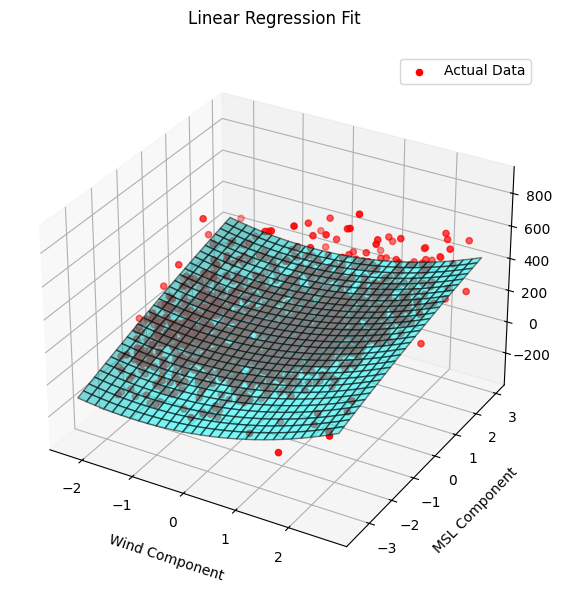

In [40]:
multi_non_linear_model(wind_component_geting_norm, msl_component_geting_norm, geting_residual_max, 2)

Intercept: 83.77724725037878
Coefficients: [ 0.         28.57503903 42.53766352 20.5930363  -5.54455004 -0.83599955
  3.79821846  8.00649285 -6.75764485  0.51792382]
Polynomial (Degree 3) R²: 0.200
MSE: 24364.631
RMSE: 156.092


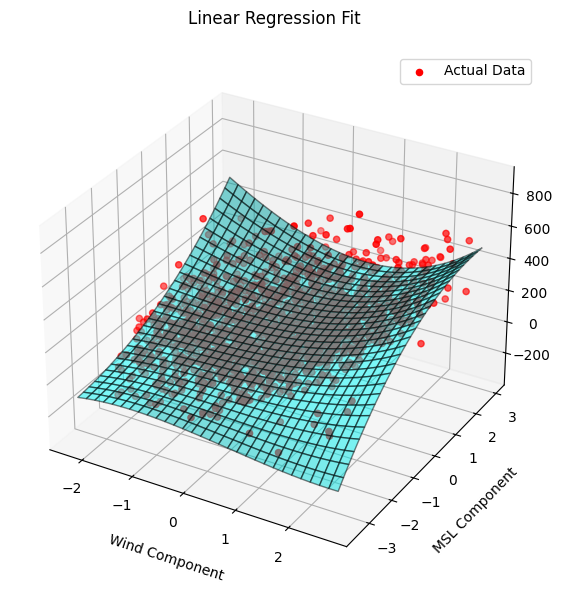

In [41]:
multi_non_linear_model(wind_component_geting_norm, msl_component_geting_norm, geting_residual_max, 3)

Intercept: 100.32652118522113
Coefficients: [ 0.         33.28294403 50.25940584]
Polynomial (Degree 1) R²: 0.180
MSE: 24960.039
RMSE: 157.987


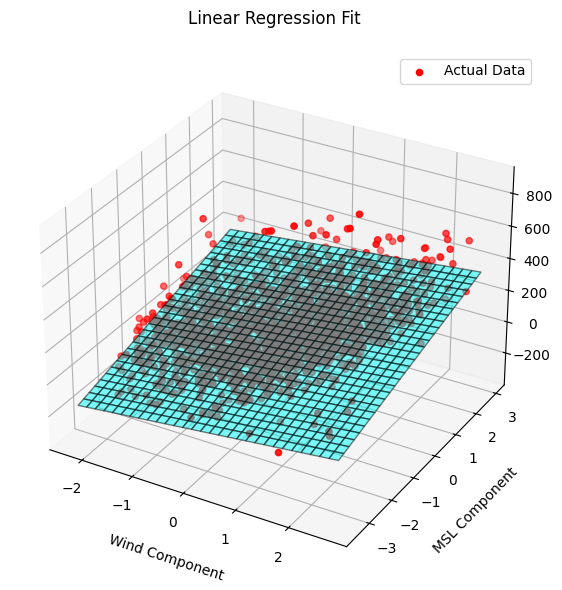

In [42]:
multi_non_linear_model(wind_component_geting_norm, msl_component_geting_norm, geting_residual_max, 1)

In [43]:
wind_new_sample = velocity(dataset_u['u'].sel(time=slice("2013-01-01", "2015-06-30")).values, dataset_v['v'].sel(time=slice("2013-01-01", "2015-06-30")).values)
msl_new_sample = np.array(dataset_msl['msl'].sel(time=slice("2013-01-01", "2015-06-30")).values)
msl_new_sample = msl_new_sample.reshape(-1)

C:\Users\SHRINJANA\AppData\Local\Temp\ipykernel_30212\964483155.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vel = math.sqrt(v_component[i]**2 + u_component[i]**2)


In [44]:
def multi_non_linear_model_predictor(wind, msl, location, degree, wind_new, msl_new):
    # Prepare input features
    x_values = pd.DataFrame({'wind': wind, 'msl': msl})
    y_values = location
    
    # Create polynomial regression model pipeline
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    x_values_new = pd.DataFrame({'wind': wind_new, 'msl': msl_new})
    # Fit the model
    poly_model.fit(x_values, y_values)
    y_poly_pred = poly_model.predict(x_values_new)
    
    return y_poly_pred

In [45]:
predicted_values = multi_non_linear_model_predictor(wind_component_geting, msl_component_geting, geting_residual_max, 2, wind_new_sample, msl_new_sample)

In [46]:
def max_cleaning_test(time, data) :
    dates = pd.to_datetime(time[1:])
    dates = dates.floor('D')  # Round down to the nearest day
    
    valid_index = data.notna().all(axis=1)  # Ensures rows have no NaN values
    dates = dates[valid_index]
    data = data[valid_index]
    
    # Filter the index based on conditions
    filtered_index = (dates.year >= 2013) & \
                    (dates.year <= 2015) & \
                    (dates.month.isin([11, 12, 1, 2])) & \
                    (dates.month != 2) & \
                    (dates.day != 29)

# Apply filtering to both dates and geting_residual
    filtered_dates = dates[filtered_index]
    filtered_residual = data[filtered_index]

# Group by date and find the maximum tide value
    daily_max_tide = filtered_residual.groupby(filtered_dates).max()
    daily_max_tide = daily_max_tide[daily_max_tide.columns[2]]
    final_dates = daily_max_tide.index
    return daily_max_tide, final_dates

In [47]:
t, u = max_cleaning_test(geting_hourly['time'].values, geting_residual)

In [48]:
t

2013-01-01    386.954408
2013-01-02    217.707006
2013-01-03    176.165686
2013-01-04    214.752508
2013-01-05    136.302574
                 ...    
2015-12-26     47.457811
2015-12-27     92.999138
2015-12-28    130.245658
2015-12-30    -14.360404
2015-12-31    209.816872
Name: -102.914234951173, Length: 267, dtype: float64

Text(0.5, 1.0, 'degree 2 fit')

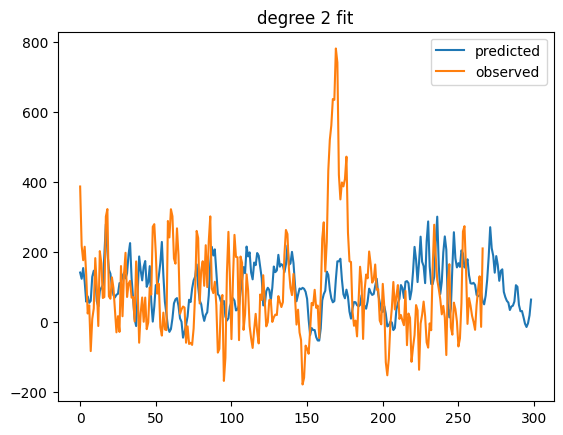

In [49]:
plt.plot(predicted_values, label='predicted')
plt.plot(t.values, label = 'observed')
plt.legend()
plt.title("degree 2 fit")

Text(0.5, 1.0, 'degree 3 fit')

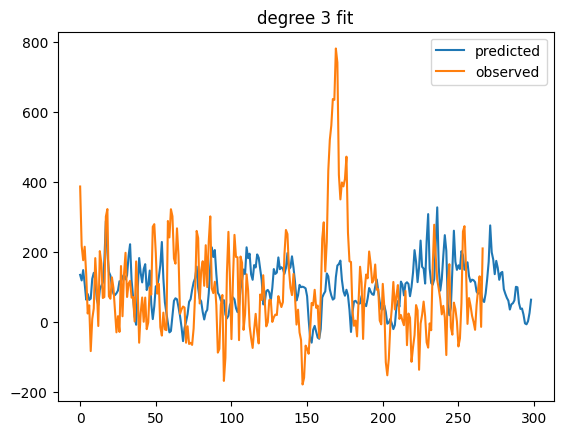

In [50]:
predicted_values = multi_non_linear_model_predictor(wind_component_geting, msl_component_geting, geting_residual_max, 3, wind_new_sample, msl_new_sample)
plt.plot(predicted_values, label='predicted')
plt.plot(t.values, label = 'observed')
plt.legend()
plt.title("degree 3 fit")

Text(0.5, 1.0, 'degree 1 fit')

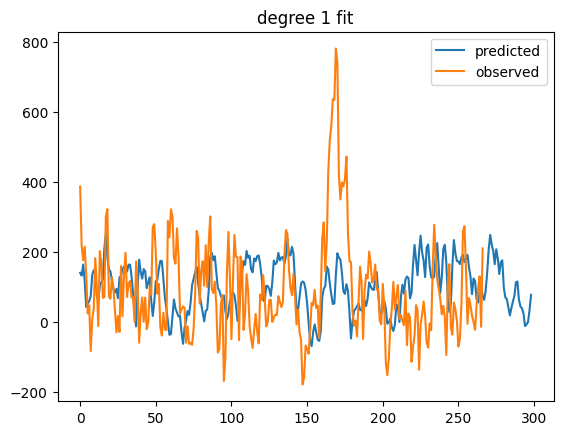

In [51]:
predicted_values = multi_non_linear_model_predictor(wind_component_geting, msl_component_geting, geting_residual_max, 1, wind_new_sample, msl_new_sample)
plt.plot(predicted_values, label='predicted')
plt.plot(t.values, label = 'observed')
plt.legend()
plt.title("degree 1 fit")

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [53]:
def forest_predictor(wind, msl, location, wind_new, msl_new):
    x_values = pd.DataFrame({'wind': wind, 'msl': msl})
    y_values = location
    X_train, X_test, y_train, y_test = train_test_split(x_values, y_values, test_size=0.2, random_state=42)

# Initialize and train the model
    rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)

# Make predictions
    y_pred = rf.predict(X_test)

# Evaluate
    x_values = pd.DataFrame({'wind': wind_new, 'msl': msl_new})
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error: {mse:.2f}")
    prediction = rf.predict(x_values)
    
    return prediction


principal component analysis

In [54]:
X = pd.DataFrame({'wind': wind_component_geting_norm, 'msl': msl_component_geting_norm})

In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assume X is your original feature DataFrame (not including the target y)
# For example:
# X = pd.DataFrame(...)

# 1. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
# Let's say you want to keep 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Wrap it in a DataFrame for inspection
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print(X_pca_df.head())


        PC1       PC2
0 -1.067879  0.179289
1  0.051602 -0.168181
2  0.840417 -0.123720
3  1.344317  0.450067
4  1.120735  0.471090


In [56]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.77795888 0.22204112]
Total variance explained: 1.0


In [57]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"Number of components to explain 95% variance: {pca.n_components_}")


Number of components to explain 95% variance: 2


In [58]:
u_component_tp = flatten_data(dataset_u, dates_tp, 'u')
v_component_tp = flatten_data(dataset_v, dates_tp, 'v')
msl_component_tp = np.array(flatten_data(dataset_msl, dates_tp, 'msl'))
wind_component_tp = np.array(velocity(u_component_tp, v_component_tp))
msl_component_tp_norm = (msl_component_tp-np.mean(msl_component_tp))/np.std(msl_component_tp)
wind_component_tp_norm = (wind_component_tp-np.mean(wind_component_tp))/np.std(msl_component_tp)

In [59]:
u_component_cendering = flatten_data(dataset_u, dates_cendering, 'u')
v_component_cendering = flatten_data(dataset_v, dates_cendering, 'v')
msl_component_cendering = np.array(flatten_data(dataset_msl, dates_cendering, 'msl'))
wind_component_cendering = np.array(velocity(u_component_cendering, v_component_cendering))
msl_component_cendering_norm = (msl_component_cendering-np.mean(msl_component_cendering))/np.std(msl_component_cendering)
wind_component_cendering_norm = (wind_component_cendering-np.mean(wind_component_cendering))/np.std(msl_component_cendering)

In [60]:
u_component_kuantan = flatten_data(dataset_u, dates_kuantan, 'u')
v_component_kuantan = flatten_data(dataset_v, dates_kuantan, 'v')
msl_component_kuantan = np.array(flatten_data(dataset_msl, dates_kuantan, 'msl'))
wind_component_kuantan = np.array(velocity(u_component_kuantan, v_component_kuantan))
msl_component_kuantan_norm = (msl_component_kuantan-np.mean(msl_component_kuantan))/np.std(msl_component_kuantan)
wind_component_kuantan_norm = (wind_component_kuantan-np.mean(wind_component_kuantan))/np.std(msl_component_kuantan)

In [61]:
u_component_jb = flatten_data(dataset_u, dates_jb, 'u')
v_component_jb = flatten_data(dataset_v, dates_jb, 'v')
msl_component_jb = np.array(flatten_data(dataset_msl, dates_jb, 'msl'))
wind_component_jb = np.array(velocity(u_component_jb, v_component_jb))
msl_component_jb_norm = (msl_component_jb-np.mean(msl_component_jb))/np.std(msl_component_jb)
wind_component_jb_norm = (wind_component_jb-np.mean(wind_component_jb))/np.std(msl_component_jb)

In [62]:
u_component_sedili = flatten_data(dataset_u, dates_sedili, 'u')
v_component_sedili = flatten_data(dataset_v, dates_sedili, 'v')
msl_component_sedili = np.array(flatten_data(dataset_msl, dates_sedili, 'msl'))
wind_component_sedili = np.array(velocity(u_component_sedili, v_component_sedili))
msl_component_sedili_norm = (msl_component_sedili-np.mean(msl_component_sedili))/np.std(msl_component_sedili)
wind_component_sedili_norm = (wind_component_sedili-np.mean(wind_component_sedili))/np.std(msl_component_sedili)

In [63]:
u_component_tioman = flatten_data(dataset_u, dates_tioman, 'u')
v_component_tioman = flatten_data(dataset_v, dates_tioman, 'v')
msl_component_tioman = np.array(flatten_data(dataset_msl, dates_tioman, 'msl'))
wind_component_tioman = np.array(velocity(u_component_tioman, v_component_tioman))
msl_component_tioman_norm = (msl_component_tioman-np.mean(msl_component_tioman))/np.std(msl_component_tioman)
wind_component_tioman_norm = (wind_component_tioman-np.mean(wind_component_tioman))/np.std(msl_component_tioman)

In [64]:
X = pd.DataFrame({'wind': wind_component_tioman_norm, 'msl':msl_component_tioman_norm})
y = tioman_residual_max

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Model Building & Evaluation ---
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV # LassoCV just for comparison maybe
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
# For VIF calculation
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Robustness Checks ---
from sklearn.utils import resample


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

# Scale the features (IMPORTANT for Ridge Regression)
# Fit scaler ONLY on training data, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = np.logspace(-4, 4, 100)

# RidgeCV automatically performs cross-validation to find the best alpha
# Use the NumPy arrays X_train_scaled here
ridge_cv_model = RidgeCV(alphas=alphas, store_cv_values=True, scoring='neg_mean_squared_error')
ridge_cv_model.fit(X_train_scaled, y_train) # Fit on scaled training data

best_alpha = ridge_cv_model.alpha_
print(f"Best alpha found via Cross-Validation: {best_alpha:.4f}")

features = ['wind', 'msl']

# Use the best alpha to train the final Ridge model
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_train_scaled, y_train) # Fit on scaled training data

# Print Coefficients (less prone to inflation than MLR)
# Use the 'features' list we defined earlier to label the coefficients
print("\nRidge Coefficients:")
for feature, coef in zip(features, ridge_model.coef_): # Use the features list
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {ridge_model.intercept_:.4f}")

# Evaluate Ridge on the test set
y_pred_ridge = ridge_model.predict(X_test_scaled) # Predict on scaled test data
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"\nRidge Performance on Test Set:")
print(f"  R-squared: {r2_ridge:.4f}")
print(f"  Mean Squared Error (MSE): {mse_ridge:.4f}")
print(f"  Root Mean Squared Error (RMSE): {np.sqrt(mse_ridge):.4f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_ridge):.4f}")

Best alpha found via Cross-Validation: 17.8865

Ridge Coefficients:
  wind: 25.6736
  msl: 39.8501
  Intercept: 88.2064

Ridge Performance on Test Set:
  R-squared: 0.2386
  Mean Squared Error (MSE): 9389.9487
  Root Mean Squared Error (RMSE): 96.9017
  Mean Absolute Error (MAE): 78.6283


c:\Users\SHRINJANA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


In [66]:
wind_new_sample = np.array(wind_new_sample)
wind_new_sample = (wind_new_sample-np.mean(wind_new_sample))/np.std(wind_new_sample)
msl_new_sample = np.array(msl_new_sample)
msl_new_sample = (msl_new_sample-np.mean(msl_new_sample))/np.std(msl_new_sample)

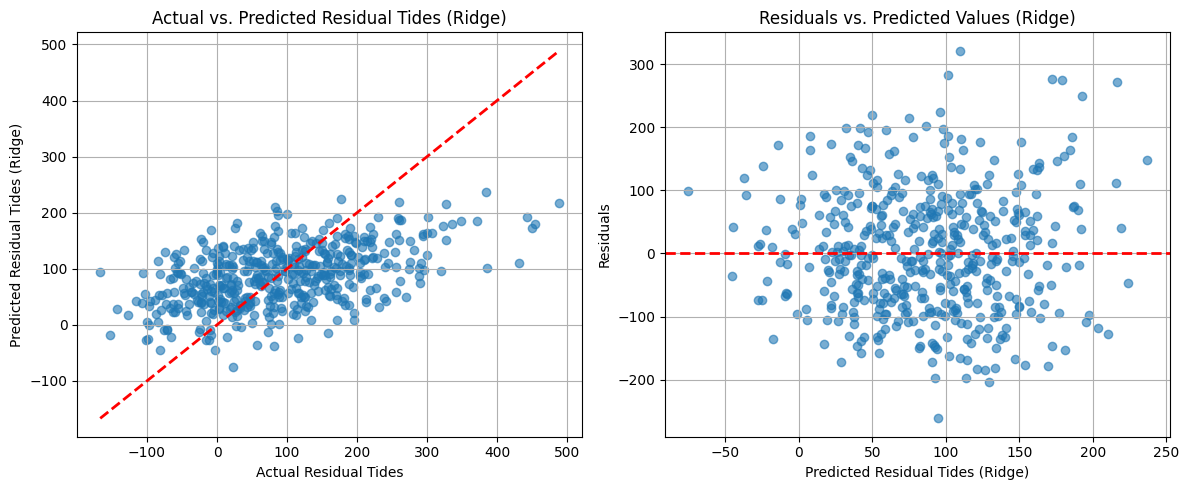

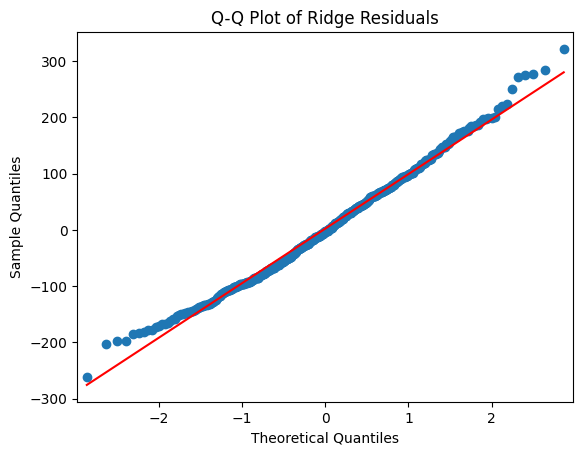

In [67]:
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted (Ridge)
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_ridge, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2)
plt.xlabel("Actual Residual Tides")
plt.ylabel("Predicted Residual Tides (Ridge)")
plt.title("Actual vs. Predicted Residual Tides (Ridge)")
plt.grid(True)

# Plot 2: Residuals vs Predicted (Ridge)
residuals_ridge = y_test - y_pred_ridge
plt.subplot(1, 2, 2)
plt.scatter(y_pred_ridge, residuals_ridge, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Residual Tides (Ridge)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values (Ridge)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Q-Q plot for Residual Normality check
sm.qqplot(residuals_ridge, line='s')
plt.title("Q-Q Plot of Ridge Residuals")
plt.show()


--- 5.1: K-Fold Cross-Validation (Ridge) ---
Cross-Validation R2 scores: [0.20392961 0.24881844 0.17175497 0.27035965 0.25533623]
  Mean R2: 0.2300 +/- 0.0366

Cross-Validation RMSE scores: [ 99.55185418  98.34888842 111.03883136 106.039546   104.05029419]
  Mean RMSE: 103.8059 +/- 4.5878

--- 5.2: Bootstrapping Coefficients (Ridge) ---


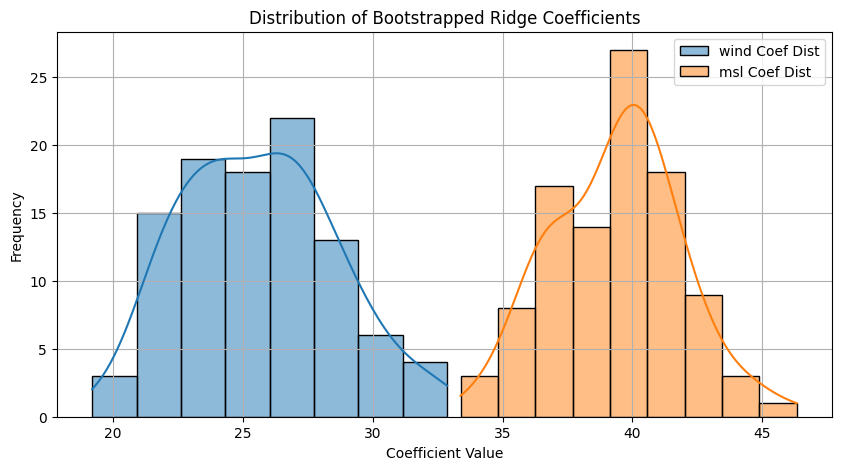


Bootstrapped 95% Confidence Intervals for Coefficients:
  wind: (20.8879, 31.9272)
  msl: (34.8706, 44.4786)

--- 5.3: Residual Analysis ---


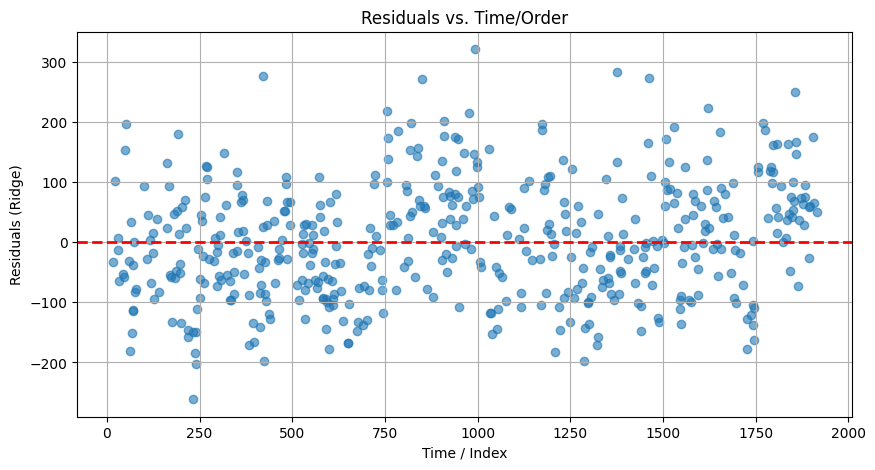


Durbin-Watson Statistic: 2.1217


In [68]:
# --- 5.1: K-Fold Cross-Validation on the *Training* Data ---
# This gives a better estimate of how the model is expected to perform on unseen data
# than a single train/test split. We use the *final* chosen model (Ridge with best alpha).
print("\n--- 5.1: K-Fold Cross-Validation (Ridge) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# Create a pipeline to ensure scaling is done correctly within each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Scaler step included here
    ('ridge', Ridge(alpha=best_alpha))
])

# Use the *original* UNscaled X_train DataFrame and y_train Series here.
# The pipeline handles scaling internally for each fold.
cv_scores_r2 = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2')
cv_scores_neg_mse = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_scores_rmse = np.sqrt(-cv_scores_neg_mse)

print(f"Cross-Validation R2 scores: {cv_scores_r2}")
print(f"  Mean R2: {np.mean(cv_scores_r2):.4f} +/- {np.std(cv_scores_r2):.4f}")
print(f"\nCross-Validation RMSE scores: {cv_scores_rmse}")
print(f"  Mean RMSE: {np.mean(cv_scores_rmse):.4f} +/- {np.std(cv_scores_rmse):.4f}")

# --- 5.2: Bootstrapping Coefficients ---
# Check the stability of the Ridge coefficients by retraining on resampled data
print("\n--- 5.2: Bootstrapping Coefficients (Ridge) ---")
n_bootstraps = 100
bootstrapped_coefs = []
bootstrapped_intercepts = []

# Use the scaled training data (NumPy array) for bootstrapping
for i in range(n_bootstraps):
    # Resample scaled training data *with replacement*
    X_boot, y_boot = resample(X_train_scaled, y_train, random_state=i)
    # Refit the Ridge model on the bootstrapped scaled data
    ridge_boot = Ridge(alpha=best_alpha)
    ridge_boot.fit(X_boot, y_boot)
    bootstrapped_coefs.append(ridge_boot.coef_)
    bootstrapped_intercepts.append(ridge_boot.intercept_)

bootstrapped_coefs = np.array(bootstrapped_coefs)

# Plot distribution of coefficients
plt.figure(figsize=(10, 5))
# Use the 'features' list for labels
for i, feature in enumerate(features):
    sns.histplot(bootstrapped_coefs[:, i], kde=True, label=f'{feature} Coef Dist')

plt.title('Distribution of Bootstrapped Ridge Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Calculate confidence intervals (e.g., 95%)
lower_bounds = np.percentile(bootstrapped_coefs, 2.5, axis=0)
upper_bounds = np.percentile(bootstrapped_coefs, 97.5, axis=0)
print("\nBootstrapped 95% Confidence Intervals for Coefficients:")
# Use the 'features' list for labels
for i, feature in enumerate(features):
    print(f"  {feature}: ({lower_bounds[i]:.4f}, {upper_bounds[i]:.4f})")

# --- 5.3: Residual Analysis (already partly done with plots) ---
print("\n--- 5.3: Residual Analysis ---")
# Checks remain the same: Normality, Homoscedasticity, Independence

# Plot Residuals vs. Time (or index if no time)
plt.figure(figsize=(10, 5))
# Use the index from the original X_test DataFrame for the x-axis
plt.scatter(X_test.index, residuals_ridge, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Time / Index")
plt.ylabel("Residuals (Ridge)")
plt.title("Residuals vs. Time/Order")
plt.grid(True)
plt.show()
# Patterns here (e.g., cycles) suggest the model is missing temporal dynamics.

# Durbin-Watson Test for autocorrelation
dw_stat = sm.stats.durbin_watson(residuals_ridge)
print(f"\nDurbin-Watson Statistic: {dw_stat:.4f}")

Intercept: 72.74579680362913
Coefficients: [0.00000000e+00 2.09457147e+03 2.88659887e+01 1.56195222e+05
 4.64389665e+02 3.44236227e-02]
Polynomial (Degree 2) R²: 0.224
MSE: 8922.568
RMSE: 94.459


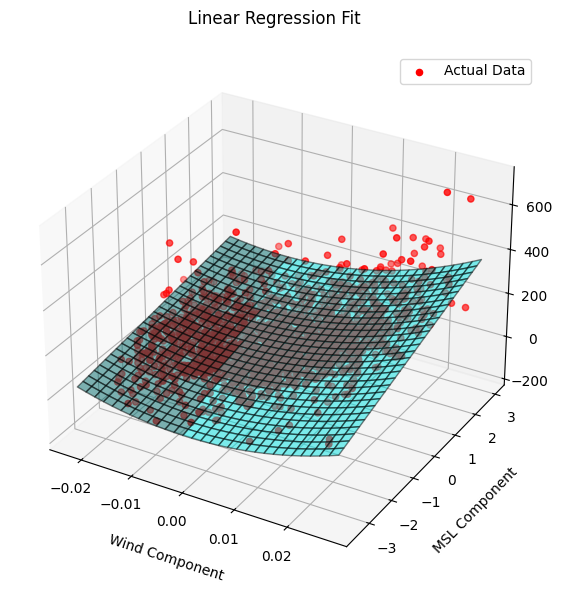

In [69]:
multi_non_linear_model(wind_component_tp_norm, msl_component_tp_norm, tp_residual_max, 2)

In [154]:
tioman_coef = pd.read_csv("cendering_tidal_constituents.csv")

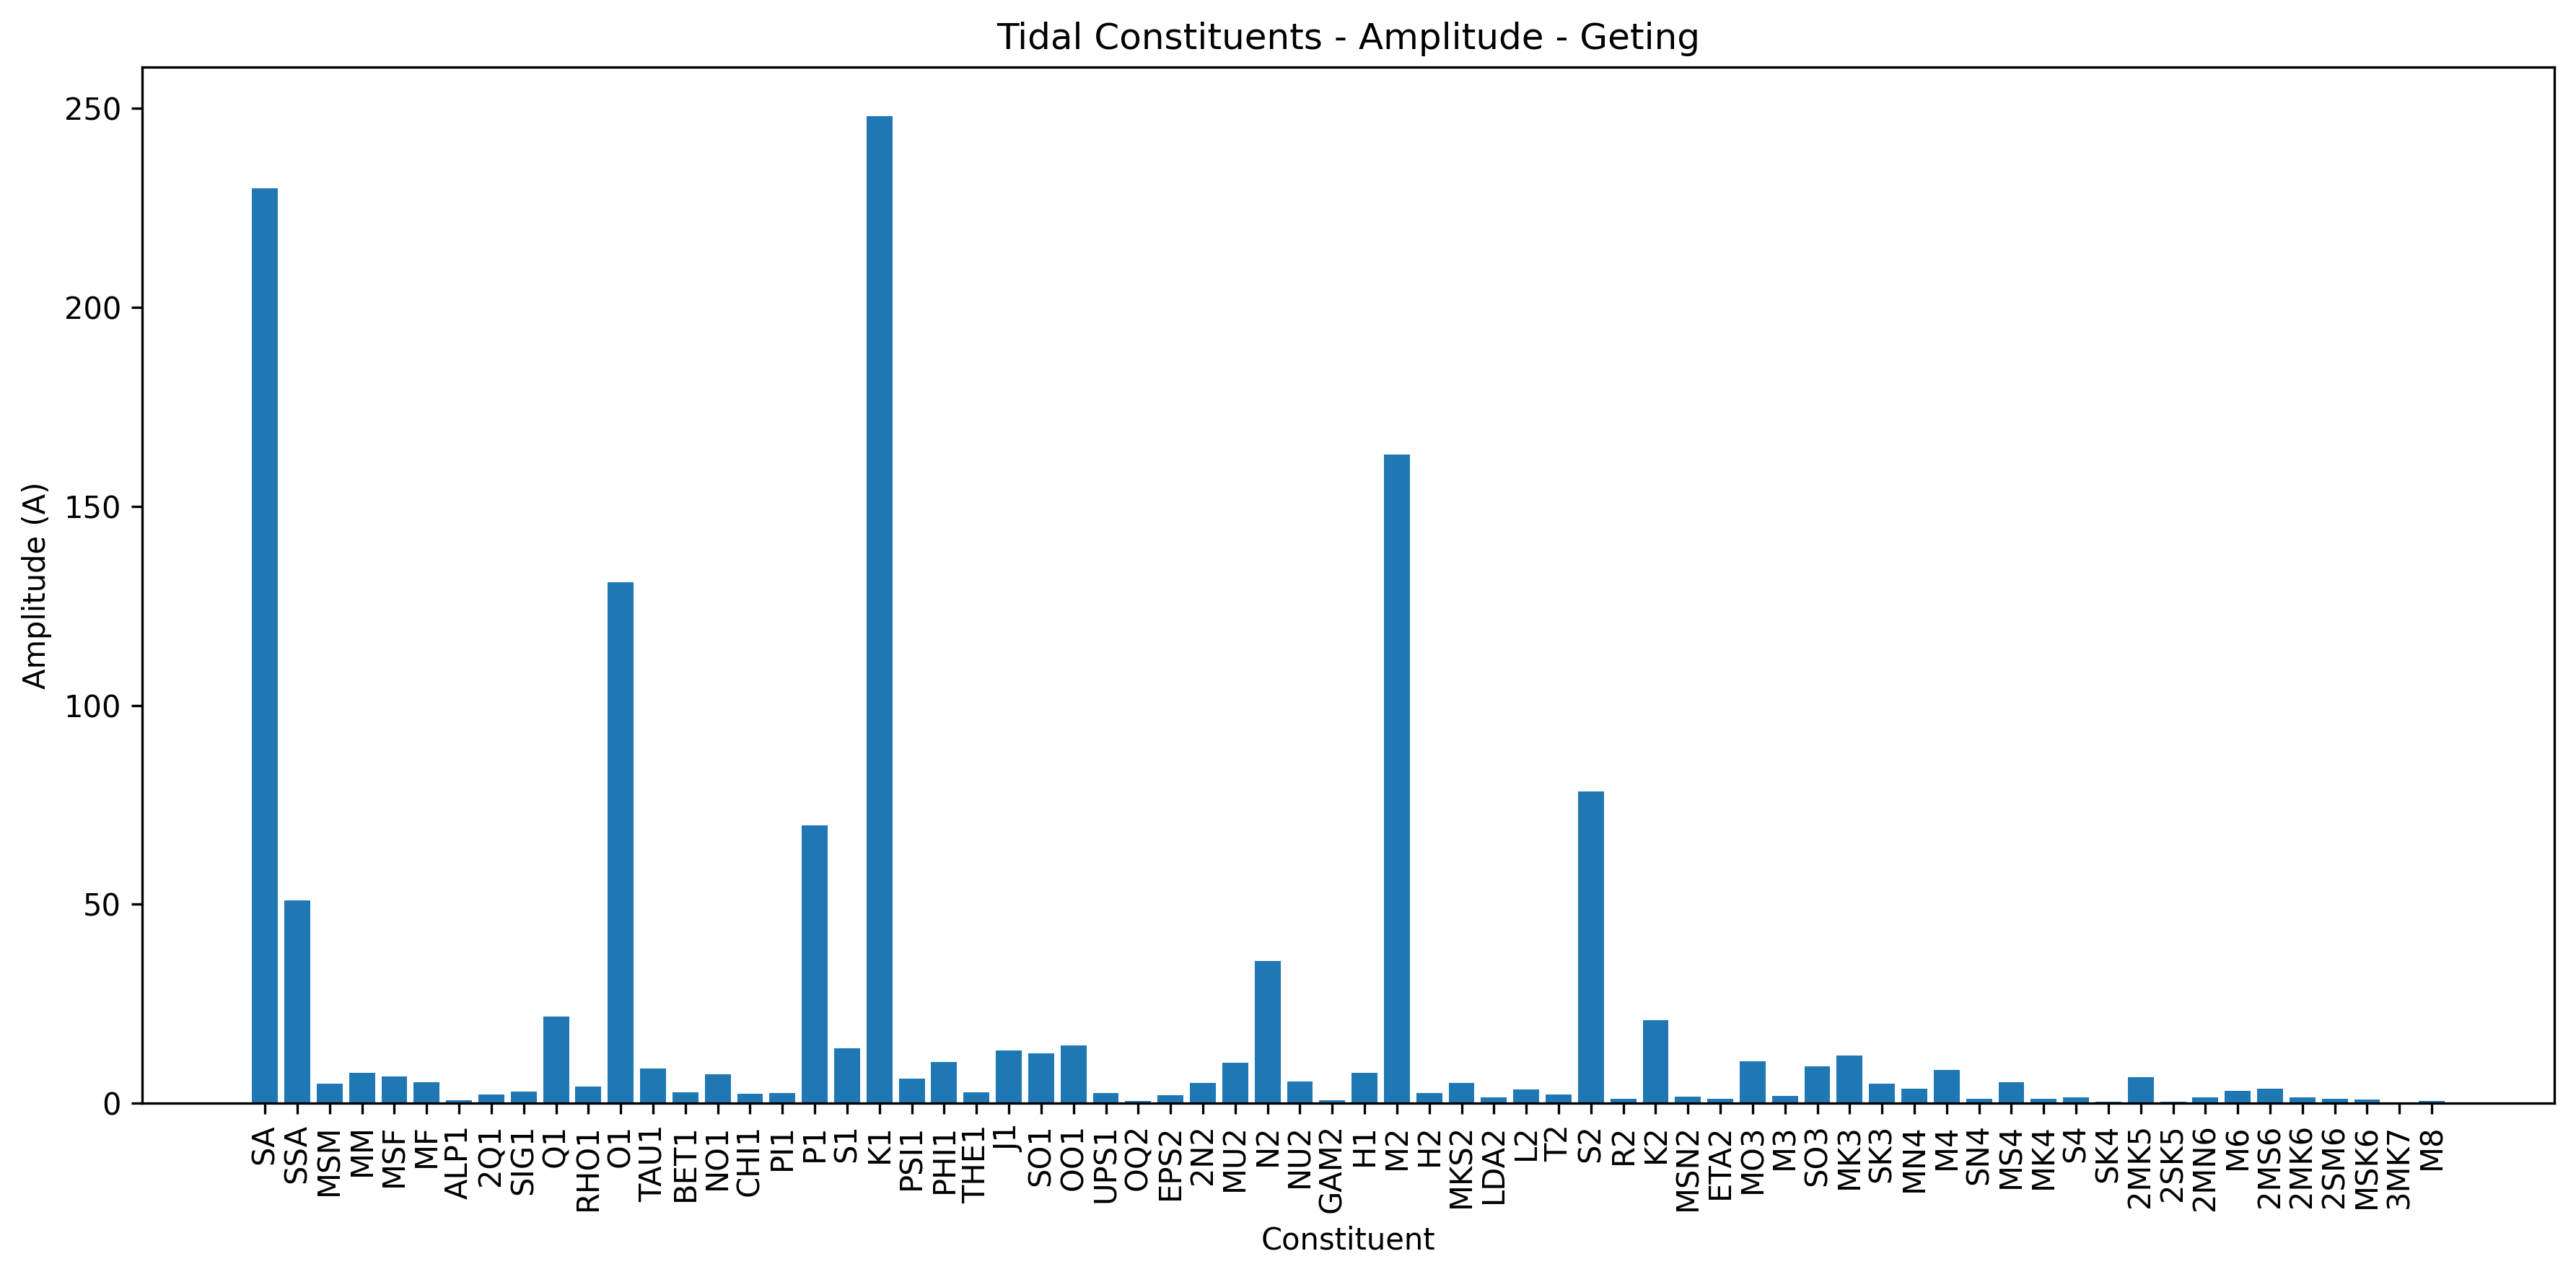

In [155]:
plt.figure(figsize=(12, 6), dpi=300)  # Width=12, Height=6 (in inches)
plt.bar(tioman_coef['Cnstit'], tioman_coef['A'])
plt.xlabel('Constituent')
plt.ylabel('Amplitude (A)')
plt.title('Tidal Constituents - Amplitude - Geting')
plt.xticks(rotation=90)  # Rotate x labels if too crowded
plt.tight_layout()       # Adjust layout to avoid clipping
plt.show()

In [153]:
geting_hourly['lat'].values

array([6.227], dtype=float32)

In [163]:
test = velocity(dataset_u['u'].values, dataset_v['v'].values)

C:\Users\SHRINJANA\AppData\Local\Temp\ipykernel_30212\964483155.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vel = math.sqrt(v_component[i]**2 + u_component[i]**2)


In [168]:
test = dataset_msl['msl'].values.reshape(-1)

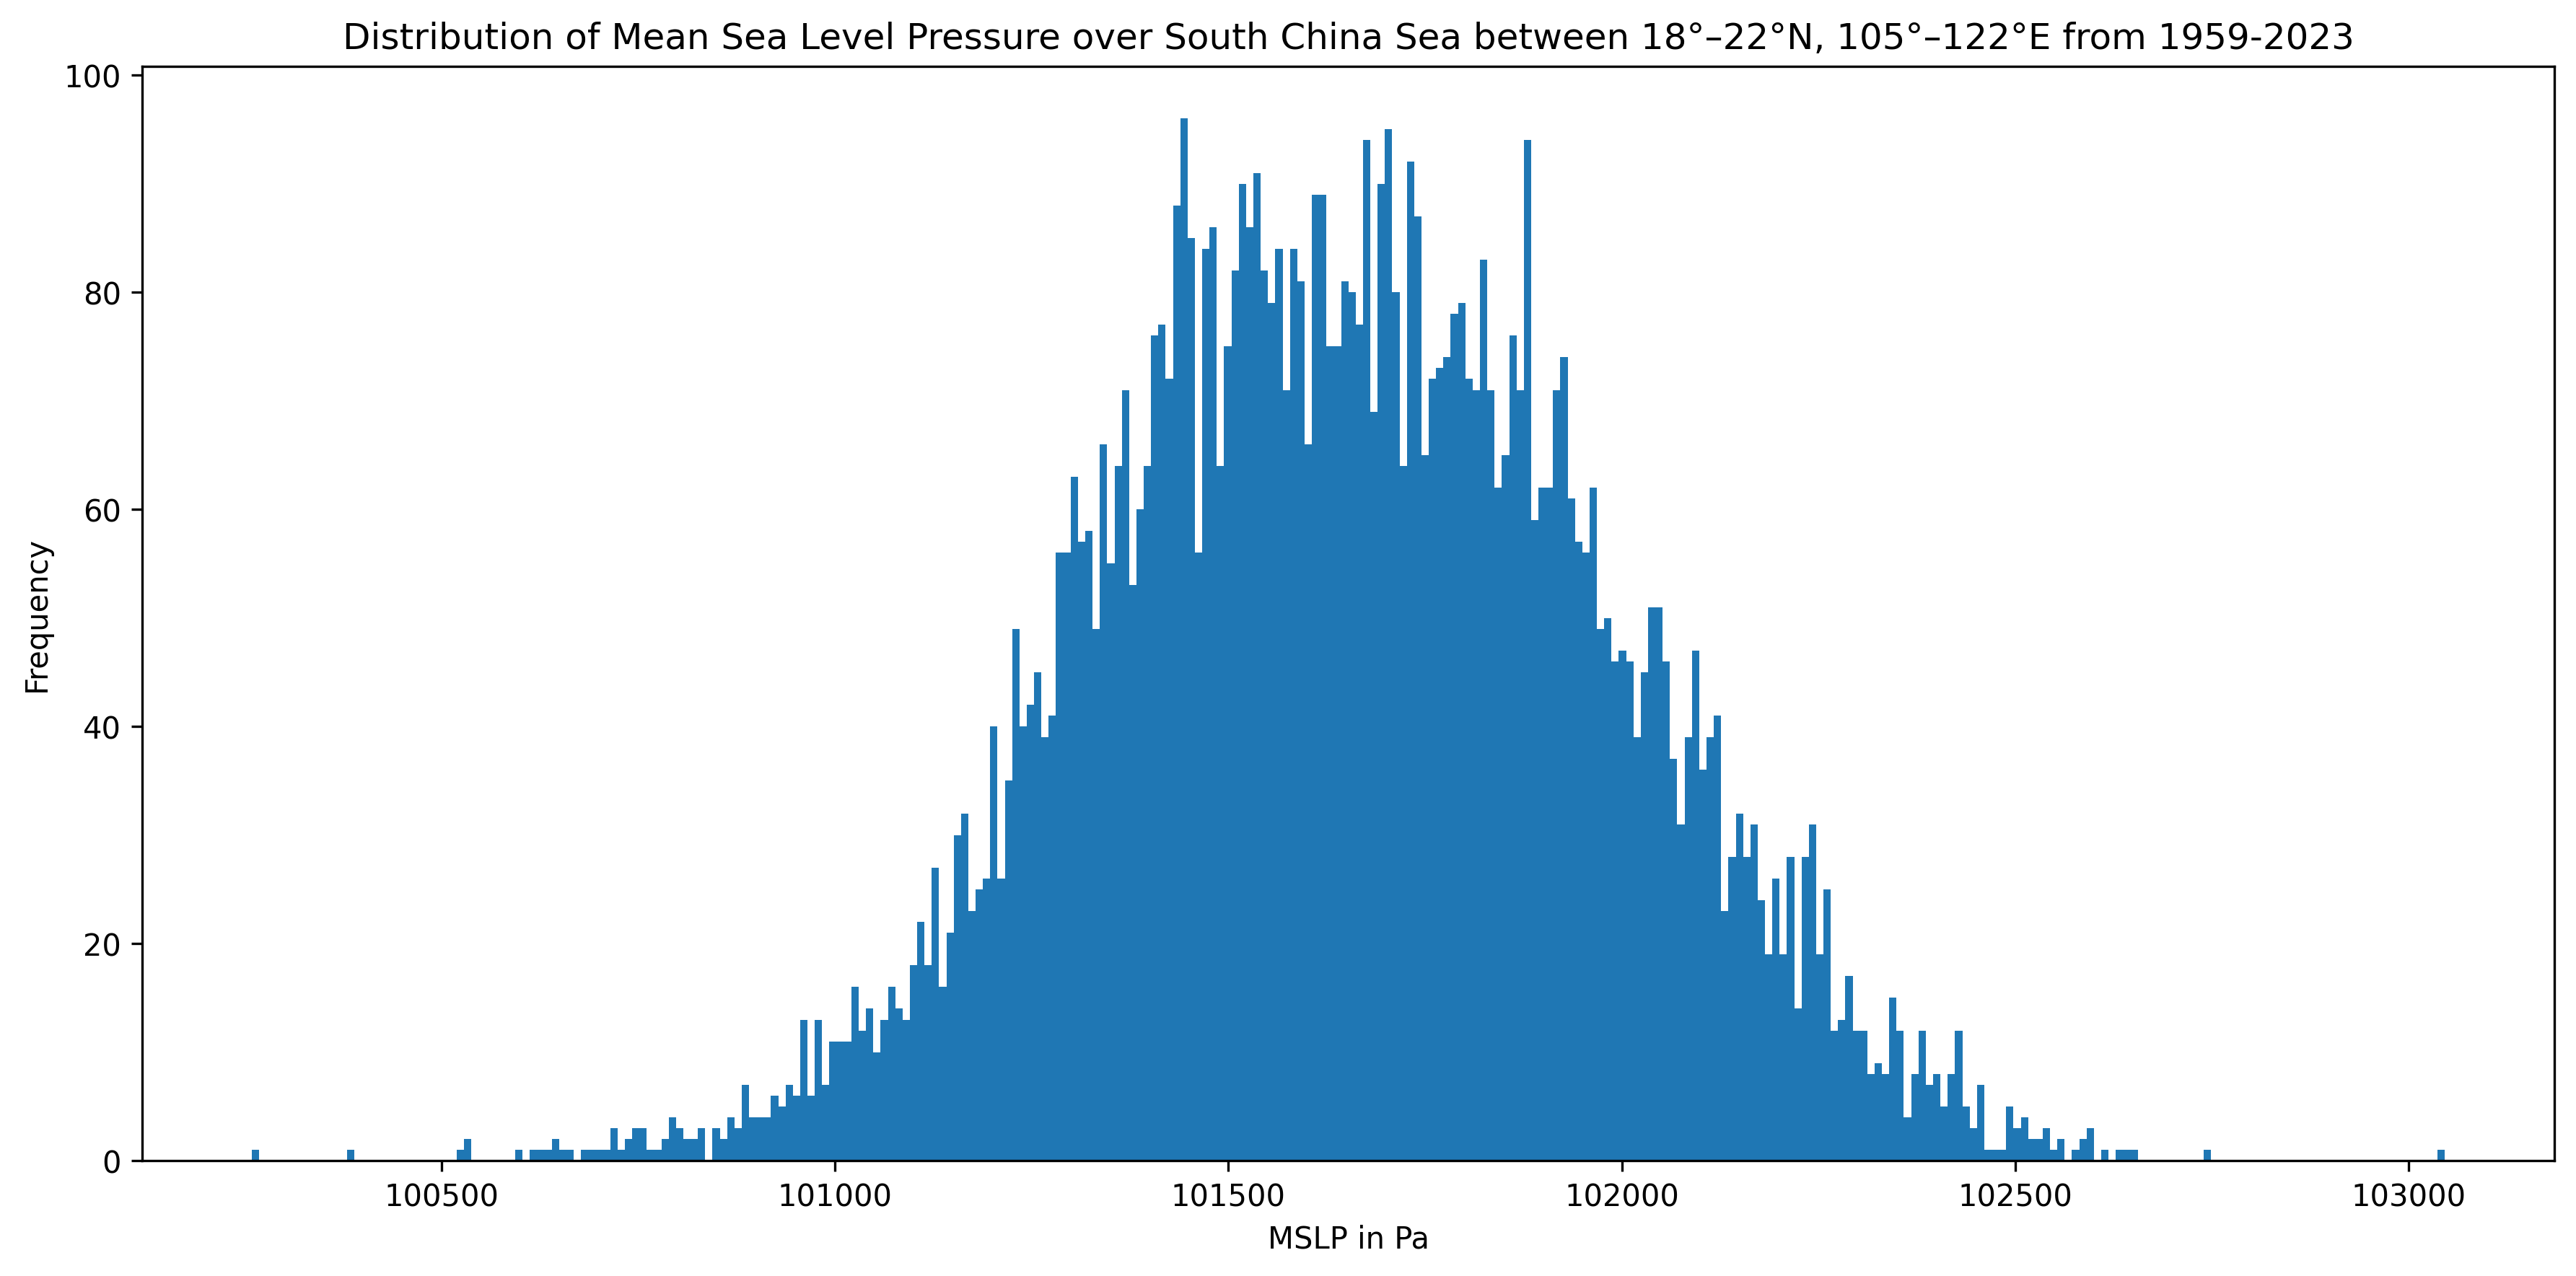

In [171]:
plt.figure(figsize=(12, 6), dpi=300)
plt.hist(test, bins = 300)
plt.title("Distribution of Mean Sea Level Pressure over South China Sea between 18°–22°N, 105°–122°E from 1959-2023")
plt.xlabel("MSLP in Pa")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [186]:
a = tp_residual[tp_residual.columns[2]].quantile(0.99)
b = tp_residual[tp_residual.columns[2]][tp_residual[tp_residual.columns[2]] > a]

In [191]:
tp_residual_max

1990-01-01     56.172153
1990-01-02     64.891302
1990-01-03     65.812802
1990-01-04    113.902625
1990-01-05    151.374155
                 ...    
2011-12-26    325.621209
2011-12-27    243.894511
2011-12-28    230.210465
2011-12-30    151.525964
2011-12-31     62.173541
Name: 58.0069078182223, Length: 1858, dtype: float64

In [192]:
wind_component_tp_norm

array([-0.00608935, -0.00061424,  0.00529536, ...,  0.01604455,
        0.00568764,  0.00153719])

In [193]:
msl_component_tp_norm

array([-0.86788464,  0.1763079 ,  0.7061484 , ...,  0.7206236 ,
        1.1884378 ,  1.1850121 ], dtype=float32)

In [385]:
kuantan_model_mae = {}

r2_score:0.11708577575912116
mae: 56.63797948470491


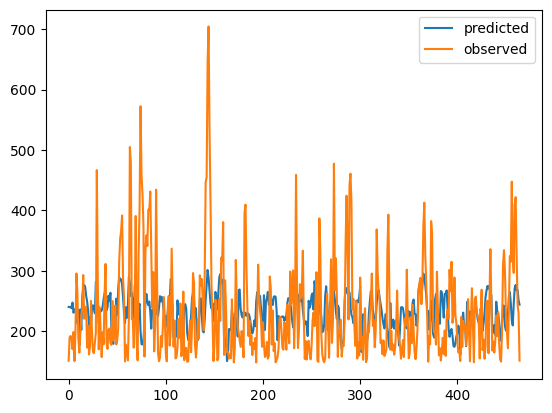

In [403]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# 1. Find 95th percentile
p95 = tp_residual_max.quantile(0.75)

# 2. Get indices where tp > 95th percentile
high_tp_idx = np.where(tp_residual_max > p95)[0]

# 3. Get corresponding wind and MSL values
X_high = np.column_stack((
    wind_component_tp_norm[high_tp_idx],
    msl_component_tp_norm[high_tp_idx]
))

X = np.column_stack((
    wind_component_tp_norm,
    msl_component_tp_norm
))

# 4. Target values: tp_residual_max on high days
y_high = tp_residual_max.values[high_tp_idx]

# 5. Train regression model
model = LinearRegression(fit_intercept=True)
model.fit(X_high, y_high)

# 6. Predict and evaluate
y_pred = model.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

r2_score:0.14102598188853155
mae: 46.820552807790854


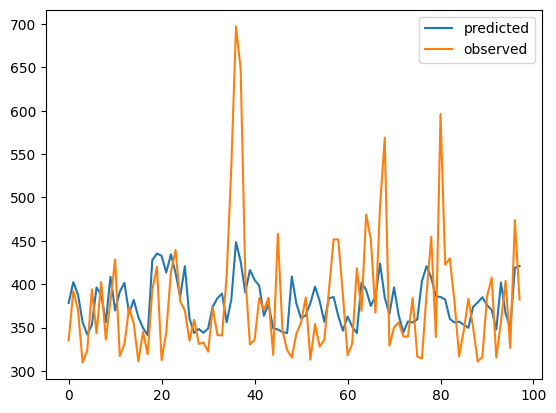

In [387]:
model_poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression(fit_intercept=True))
model_poly2.fit(X_high, y_high)

# 6. Predict and evaluate
y_pred = model_poly2.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
kuantan_model_mae['mae_95_poly_2'] = mean_absolute_error(y_high, y_pred)
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

In [404]:
tp_model_mae_percentiles = {}

r2_score:0.7948975522776047
mae: 16.82135939421691


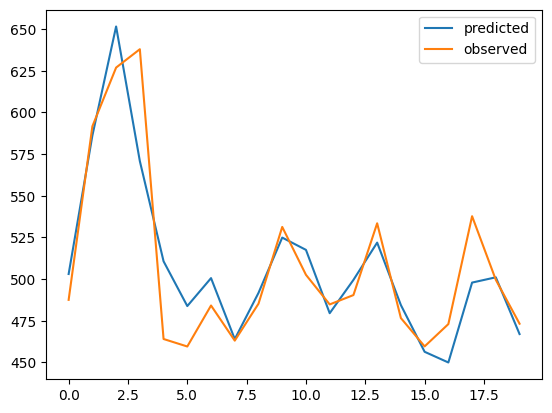

In [418]:
p95 = cendering_residual_max.quantile(0.99)

# 2. Get indices where tp > 95th percentile
high_tp_idx = np.where(cendering_residual_max > p95)[0]

# 3. Get corresponding wind and MSL values
X_high = np.column_stack((
    wind_component_cendering_norm[high_tp_idx],
    msl_component_cendering_norm[high_tp_idx]
))

X = np.column_stack((
    wind_component_cendering_norm,
    msl_component_cendering_norm
))

# 4. Target values: tp_residual_max on high days
y_high = cendering_residual_max.values[high_tp_idx]
model_poly3 = make_pipeline(PolynomialFeatures(3), LinearRegression(fit_intercept=True))
model_poly3.fit(X_high, y_high)
y_pred = model_poly3.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
tp_model_mae_percentiles['99th'] = mean_absolute_error(y_high, y_pred)
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

r2_score:0.04065446476297385
mae: 49.1404827593997


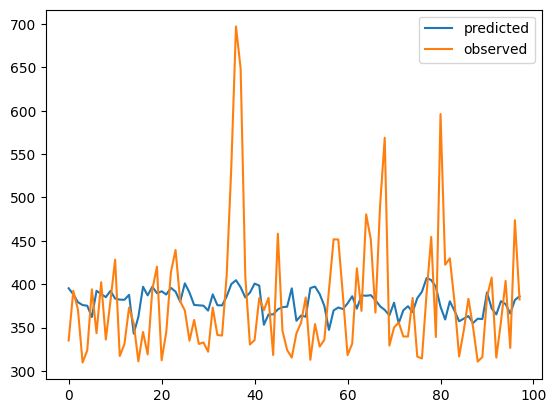

In [389]:
model_ridge = Ridge(fit_intercept=True)
model_ridge.fit(X_high, y_high)
y_pred = model_ridge.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
kuantan_model_mae['mae_95_ridge'] = mean_absolute_error(y_high, y_pred)
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

r2_score:0.03970000174344146
mae: 49.02395589827448


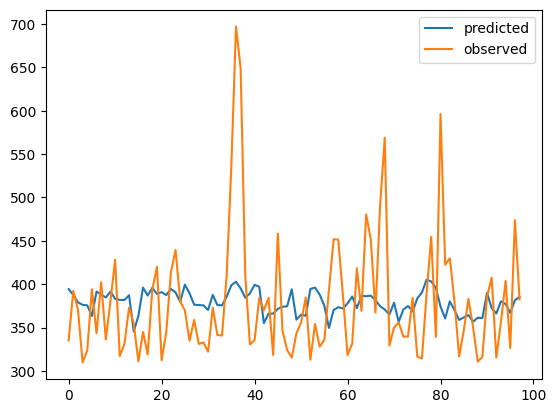

In [390]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
model_lasso = Lasso()
model_lasso.fit(X_high, y_high)
y_pred = model_lasso.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
kuantan_model_mae['mae_95_lasso'] = mean_absolute_error(y_high, y_pred)
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

r2_score:0.04065446476297385
mae: 49.1404827593997


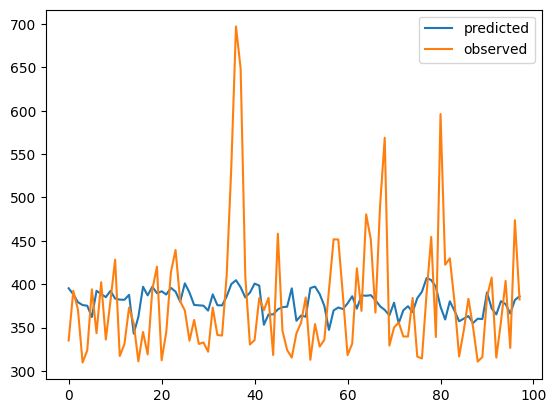

In [391]:
model_ridge_alpha1 = Ridge(alpha=1.0)
model_ridge_alpha1.fit(X_high, y_high)
y_pred = model_ridge_alpha1.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
kuantan_model_mae['mae_95_ridge_alpha1'] = mean_absolute_error(y_high, y_pred)
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

r2_score:0.04065446476297385
mae: 49.1404827593997


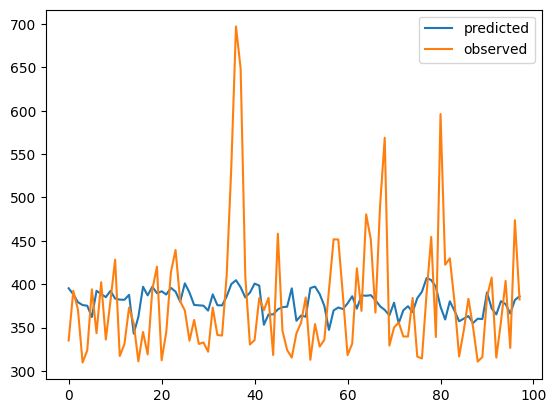

In [392]:
model_ridge_maxiter = Ridge(max_iter=1000)
model_ridge_maxiter.fit(X_high, y_high)
y_pred = model_ridge_maxiter.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
kuantan_model_mae['mae_95_ridge_maxiter'] = mean_absolute_error(y_high, y_pred)
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

r2_score:0.06830798479104938
mae: 48.59420956574473


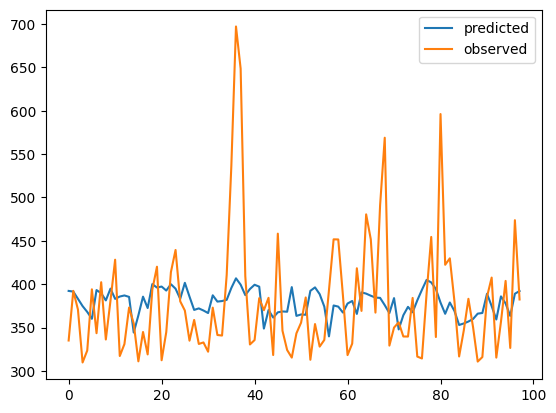

In [393]:
model_lasso_alpha01 = Lasso(alpha=0.1)
model_lasso_alpha01.fit(X_high, y_high)
y_pred = model_lasso_alpha01.predict(X_high)
print(f"r2_score:{r2_score(y_high, y_pred)}")
print(f"mae: {mean_absolute_error(y_high, y_pred)}")
kuantan_model_mae['mae_95_lasso_alpha0.1'] = mean_absolute_error(y_high, y_pred)
plt.plot(y_pred, label = "predicted")
plt.plot(y_high, label = "observed")
plt.legend()

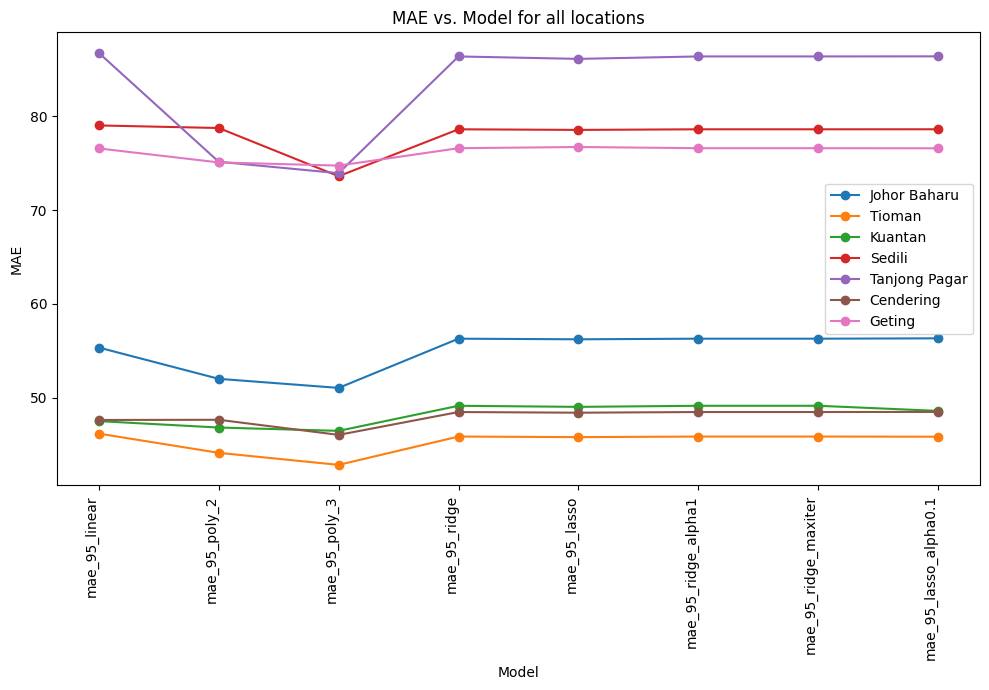

In [437]:
data = tp_model_mae_percentiles
models = list(data.keys())
mae_values = list(data.values())

plt.figure(figsize=(10, 7))
plt.plot(tp_model_mae.keys(), jb_model_mae.values(), marker='o', linestyle='-', label="Johor Baharu")
plt.plot(tp_model_mae.keys(), tioman_model_mae.values(), marker='o', linestyle='-', label="Tioman")
plt.plot(tp_model_mae.keys(), kuantan_model_mae.values(), marker='o', linestyle='-', label="Kuantan")
plt.plot(tp_model_mae.keys(), sedili_model_mae.values(), marker='o', linestyle='-', label="Sedili")
plt.plot(tp_model_mae.keys(), tp_model_mae.values(), marker='o', linestyle='-', label="Tanjong Pagar")
plt.plot(tp_model_mae.keys(), cend_model_mae.values(), marker='o', linestyle='-', label="Cendering")
plt.plot(tp_model_mae.keys(), geting_model_mae.values(), marker='o', linestyle='-', label="Geting")
plt.title('MAE vs. Model for all locations')
plt.ylabel('MAE')
plt.xlabel("Model")
plt.xticks(rotation=90, ha='right', fontsize=10)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()
plt.show()

{'mae_95_linear': 86.75756827872908,
 'mae_95_poly_2': 75.15175135292981,
 'mae_95_poly_3': 73.93750253891118,
 'mae_95_ridge': 86.38341192974532,
 'mae_95_lasso': 86.12286255871854,
 'mae_95_ridge_alpha1': 86.38341192974532,
 'mae_95_ridge_maxiter': 86.38341192974532,
 'mae_95_lasso_alpha0.1': 86.39318503255748}

In [396]:
jb_model_mae

{'mae_95_linear': 55.346974480095895,
 'mae_95_poly_2': 52.01367839749784,
 'mae_95_poly_3': 51.045477837089024,
 'mae_95_ridge': 56.29321511158796,
 'mae_95_lasso': 56.22750253528889,
 'mae_95_ridge_alpha1': 56.29321511158796,
 'mae_95_ridge_maxiter': 56.29321511158796,
 'mae_95_lasso_alpha0.1': 56.33037964959592}

In [397]:
geting_model_mae

{'mae_95_linear': 76.5752595035365,
 'mae_95_poly_2': 75.08513028423323,
 'mae_95_poly_3': 74.7463246607988,
 'mae_95_ridge': 76.60132366066426,
 'mae_95_lasso': 76.72799137784303,
 'mae_95_ridge_alpha1': 76.60132366066426,
 'mae_95_ridge_maxiter': 76.60132366066426,
 'mae_95_lasso_alpha0.1': 76.59056035464715}

In [398]:
kuantan_model_mae

{'mae_95_linear': 47.50439078025508,
 'mae_95_poly_2': 46.820552807790854,
 'mae_95_poly_3': 46.46655540072607,
 'mae_95_ridge': 49.1404827593997,
 'mae_95_lasso': 49.02395589827448,
 'mae_95_ridge_alpha1': 49.1404827593997,
 'mae_95_ridge_maxiter': 49.1404827593997,
 'mae_95_lasso_alpha0.1': 48.59420956574473}

In [399]:
sedili_model_mae

{'mae_95_linear': 79.02703415872584,
 'mae_95_poly_2': 78.753524486465,
 'mae_95_poly_3': 73.61378439061254,
 'mae_95_ridge': 78.61610027262485,
 'mae_95_lasso': 78.5511638918731,
 'mae_95_ridge_alpha1': 78.61610027262485,
 'mae_95_ridge_maxiter': 78.61610027262485,
 'mae_95_lasso_alpha0.1': 78.61847634820026}

In [400]:
tioman_model_mae

{'mae_95_linear': 46.17145508385968,
 'mae_95_poly_2': 44.12313078430727,
 'mae_95_poly_3': 42.839984075492744,
 'mae_95_ridge': 45.86019635725713,
 'mae_95_lasso': 45.7971623018023,
 'mae_95_ridge_alpha1': 45.86019635725713,
 'mae_95_ridge_maxiter': 45.86019635725713,
 'mae_95_lasso_alpha0.1': 45.84304896714937}

In [402]:
kuantan_model_mae

{'mae_95_linear': 47.50439078025508,
 'mae_95_poly_2': 46.820552807790854,
 'mae_95_poly_3': 46.46655540072607,
 'mae_95_ridge': 49.1404827593997,
 'mae_95_lasso': 49.02395589827448,
 'mae_95_ridge_alpha1': 49.1404827593997,
 'mae_95_ridge_maxiter': 49.1404827593997,
 'mae_95_lasso_alpha0.1': 48.59420956574473}

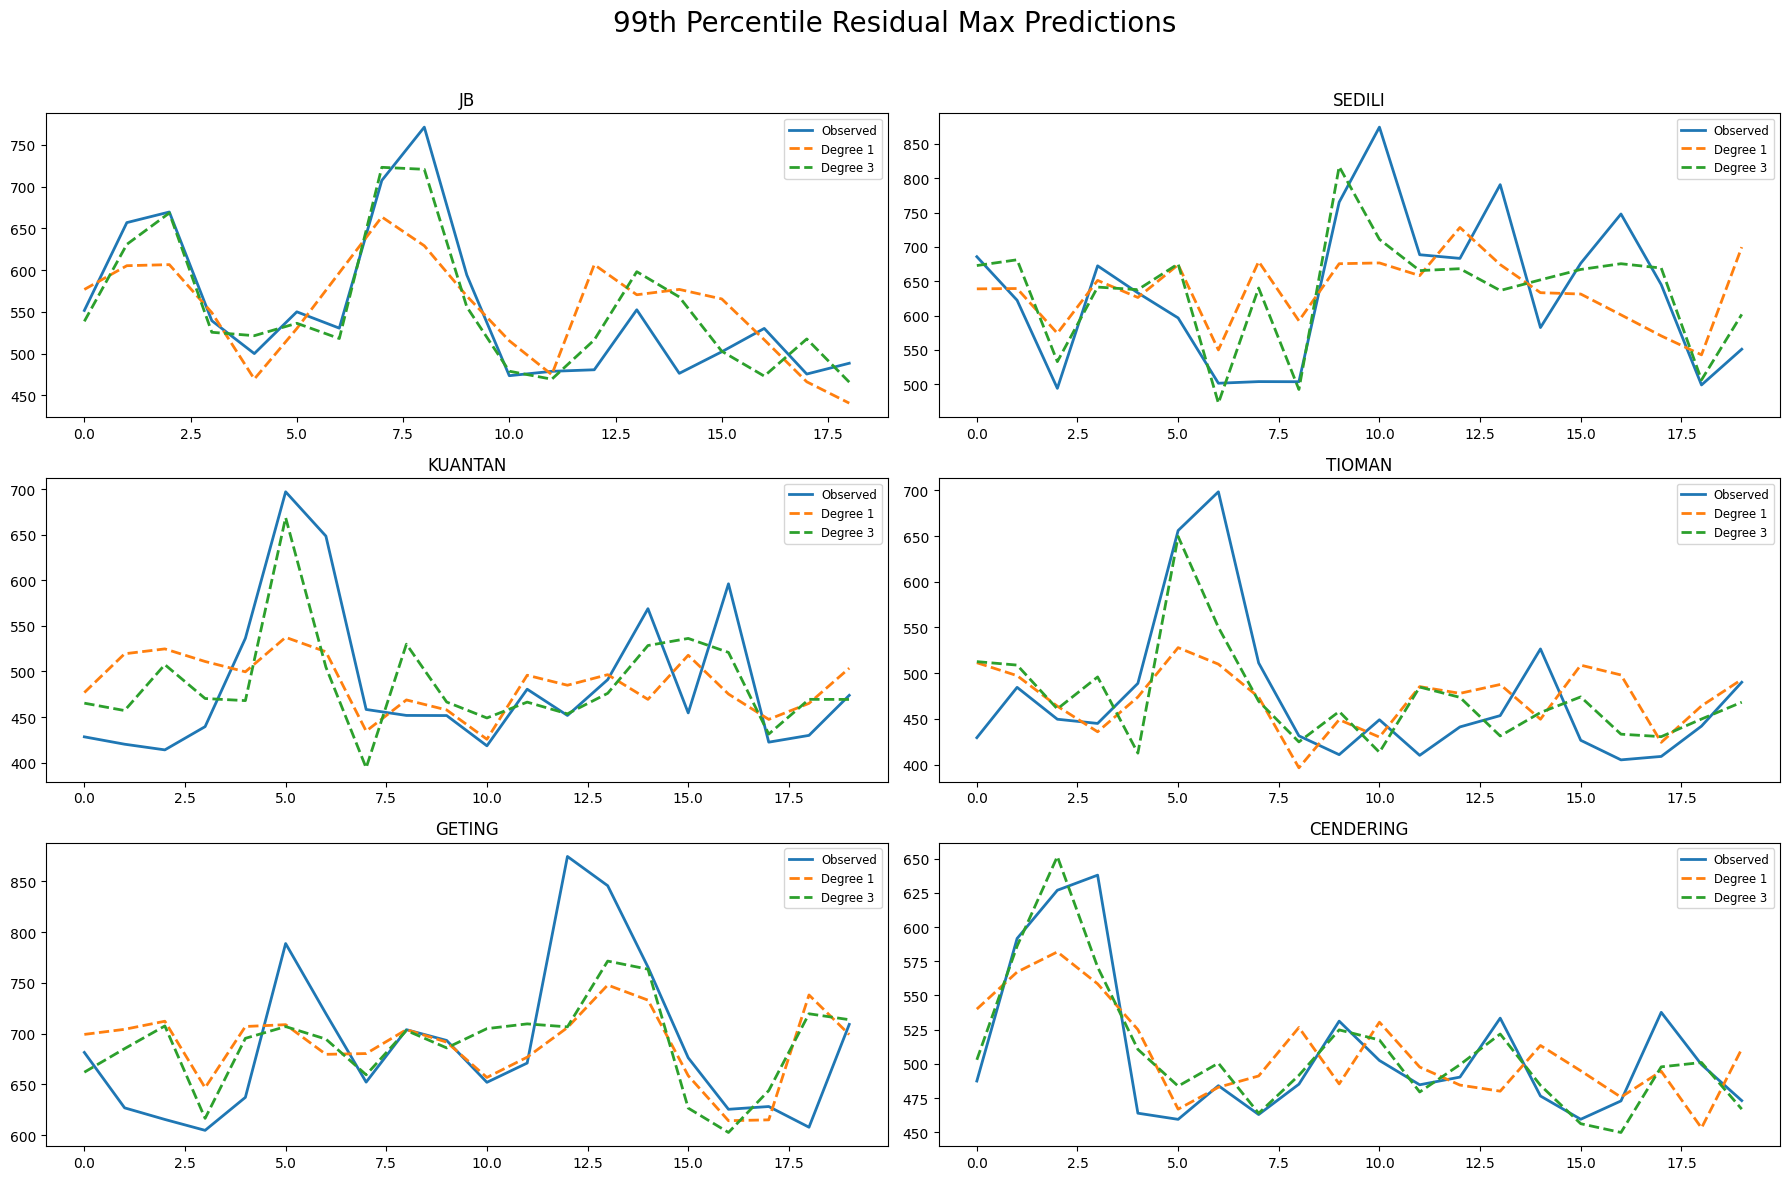

In [460]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Assuming these variables are defined for each location:
# residual_max_{loc}, wind_component_{loc}_norm, msl_component_{loc}_norm

locations = ['jb', 'sedili', 'kuantan', 'tioman', 'geting', 'cendering']
n_locations = len(locations)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))  # adjust as needed
axs = axs.flatten()

tp_model_mae_percentiles = {}

for i, loc in enumerate(locations):
    # Dynamic variable access
    residual_max = globals()[f'{loc}_residual_max']
    wind = globals()[f'wind_component_{loc}_norm']
    msl = globals()[f'msl_component_{loc}_norm']

    # 99th percentile
    p99 = residual_max.quantile(0.99)
    high_idx = np.where(residual_max > p99)[0]

    # Prepare inputs
    X_high = np.column_stack((wind[high_idx], msl[high_idx]))
    y_high = residual_max.values[high_idx]

    # Fit polynomial regression
    model = LinearRegression(fit_intercept=True)
    model.fit(X_high, y_high)
    y_pred = model.predict(X_high)
    model3 = make_pipeline(PolynomialFeatures(3), LinearRegression(fit_intercept=True))
    model3.fit(X_high, y_high)
    y_pred_3 = model3.predict(X_high)

    # Compute MAE
    mae = mean_absolute_error(y_high, y_pred)
    tp_model_mae_percentiles[loc] = mae

    # Plot
    ax = axs[i]
    ax.plot(y_high, label='Observed', linewidth=2)
    ax.plot(y_pred, label='Degree 1', linestyle='--', linewidth=2)
    ax.plot(y_pred_3, label='Degree 3', linestyle='--', linewidth=2)
    #ax.set_title(f'{loc.upper()} (MAE: {mae:.2f})')
    ax.set_title(f'{loc.upper()}')
    ax.legend(fontsize='small')

# Hide any unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

fig.suptitle('99th Percentile Residual Max Predictions', fontsize=20)
fig.tight_layout(rect=[0, 0, 1, 0.96])  # adjust to fit suptitle
plt.show()


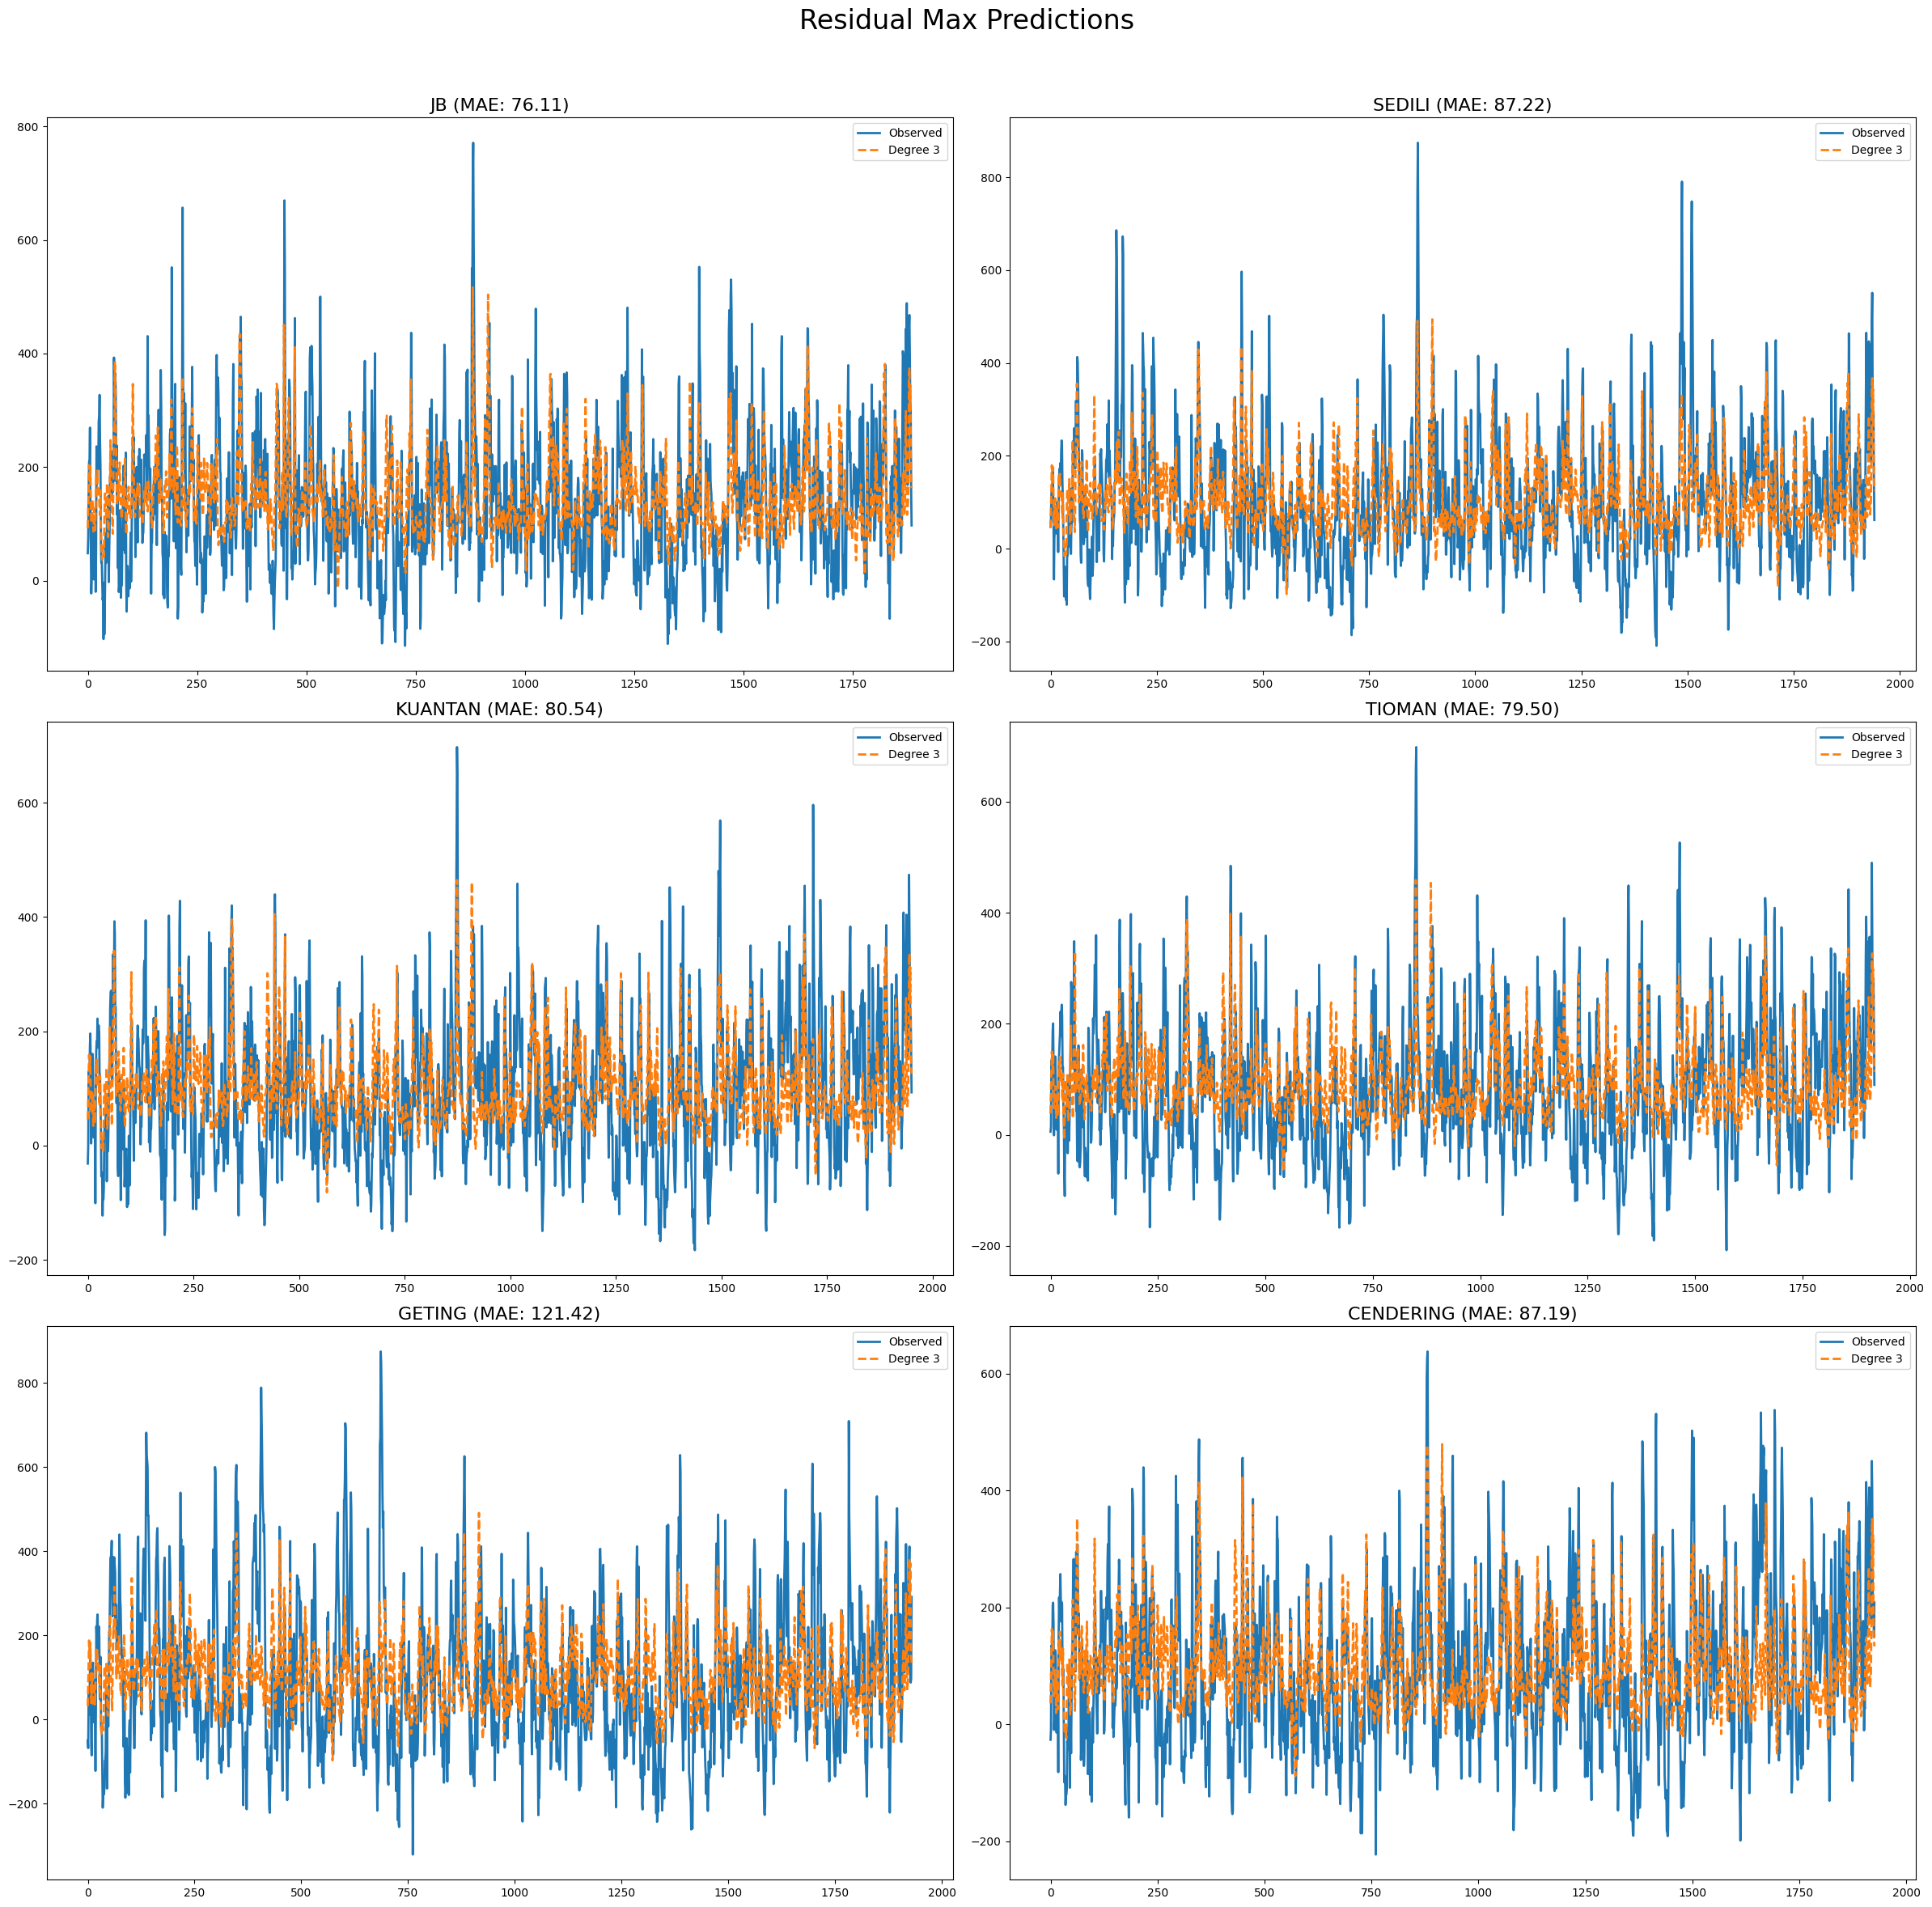

In [558]:
locations = ['jb', 'sedili', 'kuantan', 'tioman', 'geting', 'cendering']
n_locations = len(locations)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(24, 24))  # adjust as needed
axs = axs.flatten()

tp_model_mae_percentiles = {}

for i, loc in enumerate(locations):
    # Dynamic variable access
    residual_max = globals()[f'{loc}_residual_max']
    wind = globals()[f'wind_component_{loc}_norm']
    msl = globals()[f'msl_component_{loc}_norm']

    # 99th percentile
    p99 = residual_max.quantile(0.99)
    high_idx = np.where(residual_max > p99)[0]

    # Prepare inputs
    X_high = np.column_stack((wind, msl))
    y_high = residual_max.values

    model3 = make_pipeline(PolynomialFeatures(3), LinearRegression(fit_intercept=True))
    model3.fit(X_high, y_high)
    y_pred_3 = model3.predict(X_high)

    # Compute MAE
    mae = mean_absolute_error(y_high, y_pred_3)
    #tp_model_mae_percentiles[loc] = mae

    # Plot
    ax = axs[i]
    ax.plot(y_high, label='Observed', linewidth=2)
    ax.plot(y_pred_3, label='Degree 3', linestyle='--', linewidth=2)
    ax.set_title(f'{loc.upper()} (MAE: {mae:.2f})', fontsize=16)
    ax.legend()

# Hide any unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

fig.suptitle('Residual Max Predictions', fontsize=24)
fig.tight_layout(rect=[0, 0, 1, 0.96])  # adjust to fit suptitle
plt.show()


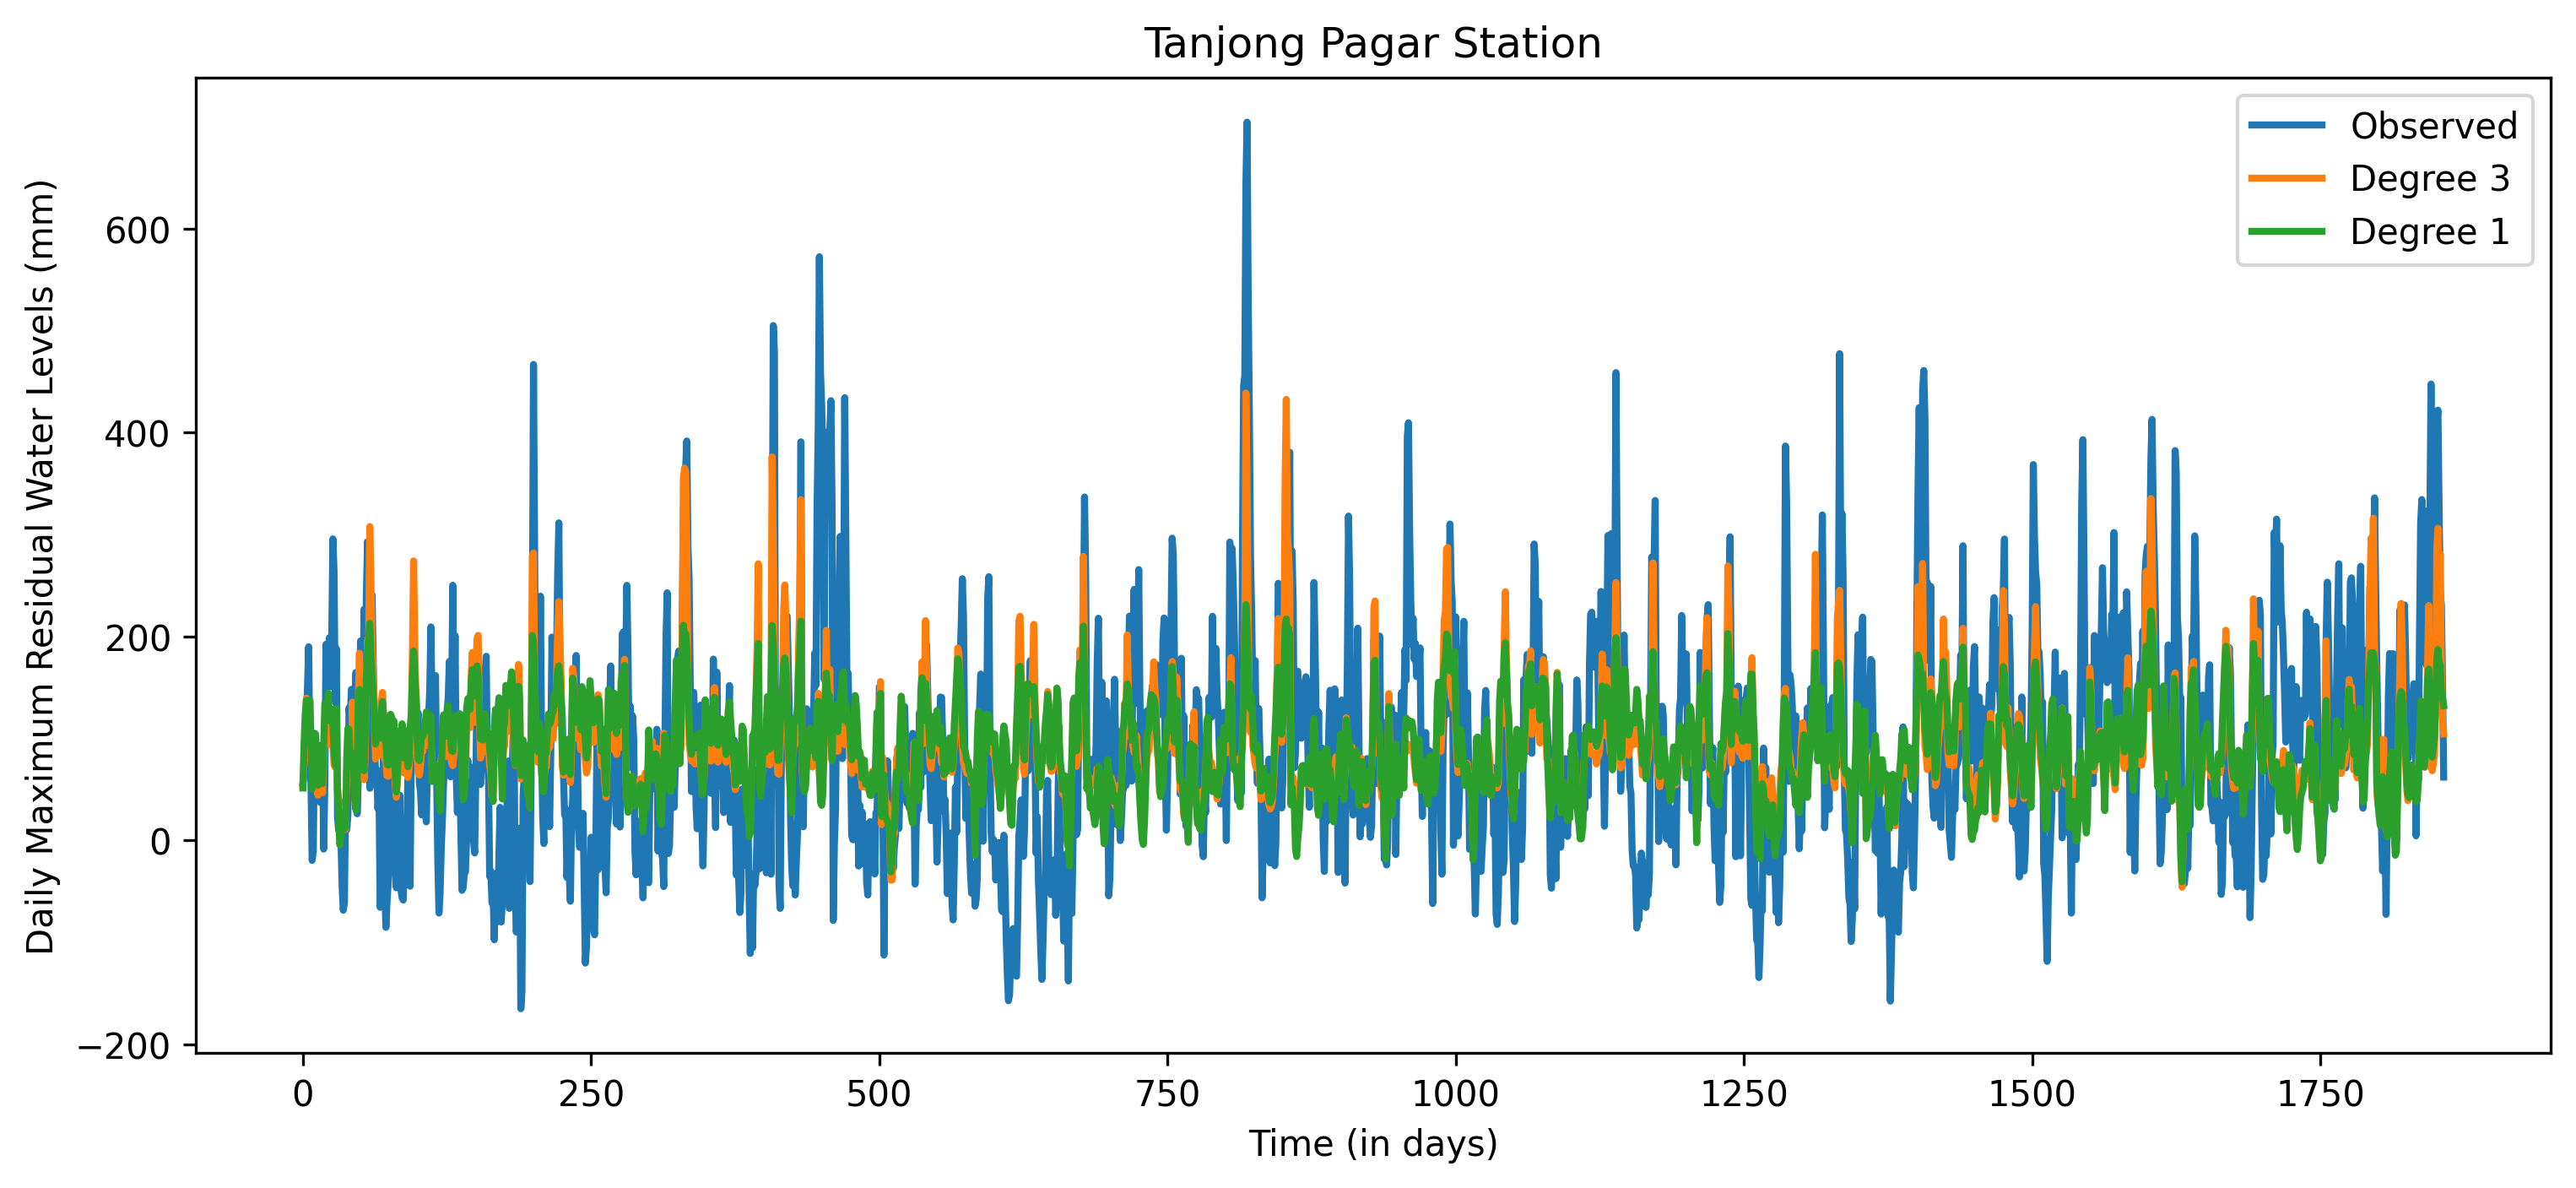

In [564]:
X_high = np.column_stack((wind_component_tp_norm, msl_component_tp_norm))
y_high = tp_residual_max.values
model = LinearRegression(fit_intercept=True)
model.fit(X_high, y_high)
model3 = make_pipeline(PolynomialFeatures(3), LinearRegression(fit_intercept=True))
model3.fit(X_high, y_high)
y_pred_3 = model3.predict(X_high)
y_pred = model.predict(X_high)

    # Compute MAE
r2 = r2_score(y_high, y_pred_3)
mae = mean_absolute_error(y_high, y_pred_3)
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(y_high, label='Observed', linewidth=2)
plt.plot(y_pred_3, label='Degree 3', linewidth=2)
plt.plot(y_pred, label='Degree 1', linewidth=2)
plt.xlabel("Time (in days)")
plt.ylabel("Daily Maximum Residual Water Levels (mm)")
plt.title("Tanjong Pagar Station")
plt.legend()
plt.show()

In [619]:
def hindcast(time, data) :
    dates = pd.to_datetime(time[1:])
    dates = dates.floor('D')  # Round down to the nearest day
    
    valid_index = data.notna().all(axis=1)  # Ensures rows have no NaN values
    dates = dates[valid_index]
    data = data[valid_index]

# Filter the index based on conditions
    filtered_index = (dates.year >= 2014) & \
                    (dates.year <= 2016) & \
                    (dates.month.isin([11, 12, 1, 2])) & \
                    (dates.month != 2) & \
                    (dates.day != 29)

# Apply filtering to both dates and geting_residual
    filtered_dates = dates[filtered_index]
    filtered_residual = data[filtered_index]

# Group by date and find the maximum tide value
    daily_max_tide = filtered_residual.groupby(filtered_dates).max()
    daily_max_tide = daily_max_tide[daily_max_tide.columns[2]]
    final_dates = daily_max_tide.index
    return daily_max_tide, final_dates

In [620]:
tp_residual_hindcast, dates_tp_hindcast = hindcast(tp_hourly['time'].values, tp_residual)

In [621]:
u_component_tp_hindcast = flatten_data(dataset_u, dates_tp_hindcast, 'u')
v_component_tp_hindcast = flatten_data(dataset_v, dates_tp_hindcast, 'v')
msl_component_tp_hindcast = np.array(flatten_data(dataset_msl, dates_tp_hindcast, 'msl'))
wind_component_tp_hindcast = np.array(velocity(u_component_tp_hindcast, v_component_tp_hindcast))
msl_component_tp_norm_hindcast = (msl_component_tp_hindcast-np.mean(msl_component_tp_hindcast))/np.std(msl_component_tp_hindcast)
wind_component_tp_norm_hindcast = (wind_component_tp_hindcast-np.mean(wind_component_tp_hindcast))/np.std(msl_component_tp_hindcast)

In [622]:
tp_residual_hindcast

2014-01-01    178.590570
2014-01-02    130.380281
2014-01-03    108.052686
2014-01-04    -14.024576
2014-01-05     91.069956
                 ...    
2016-12-26     72.365753
2016-12-27    226.929180
2016-12-28    269.348062
2016-12-30    119.141112
2016-12-31    123.586767
Name: 58.0069078182223, Length: 267, dtype: float64

In [630]:
sd = xr.open_dataset('surge-days_day_ERA5_historical_195911-202302.nc')

In [631]:
sd = sd.sel(time=slice("2014-01-01", "2016-12-31"))

In [632]:
sd_days = np.array(sd['time'].values)
sd_values = np.array(sd['surge-day'].values)

In [633]:
nan_indices = ~np.isnan(sd_values)
sd_values_clean = sd_values[nan_indices]
sd_days_clean = sd_days[nan_indices]

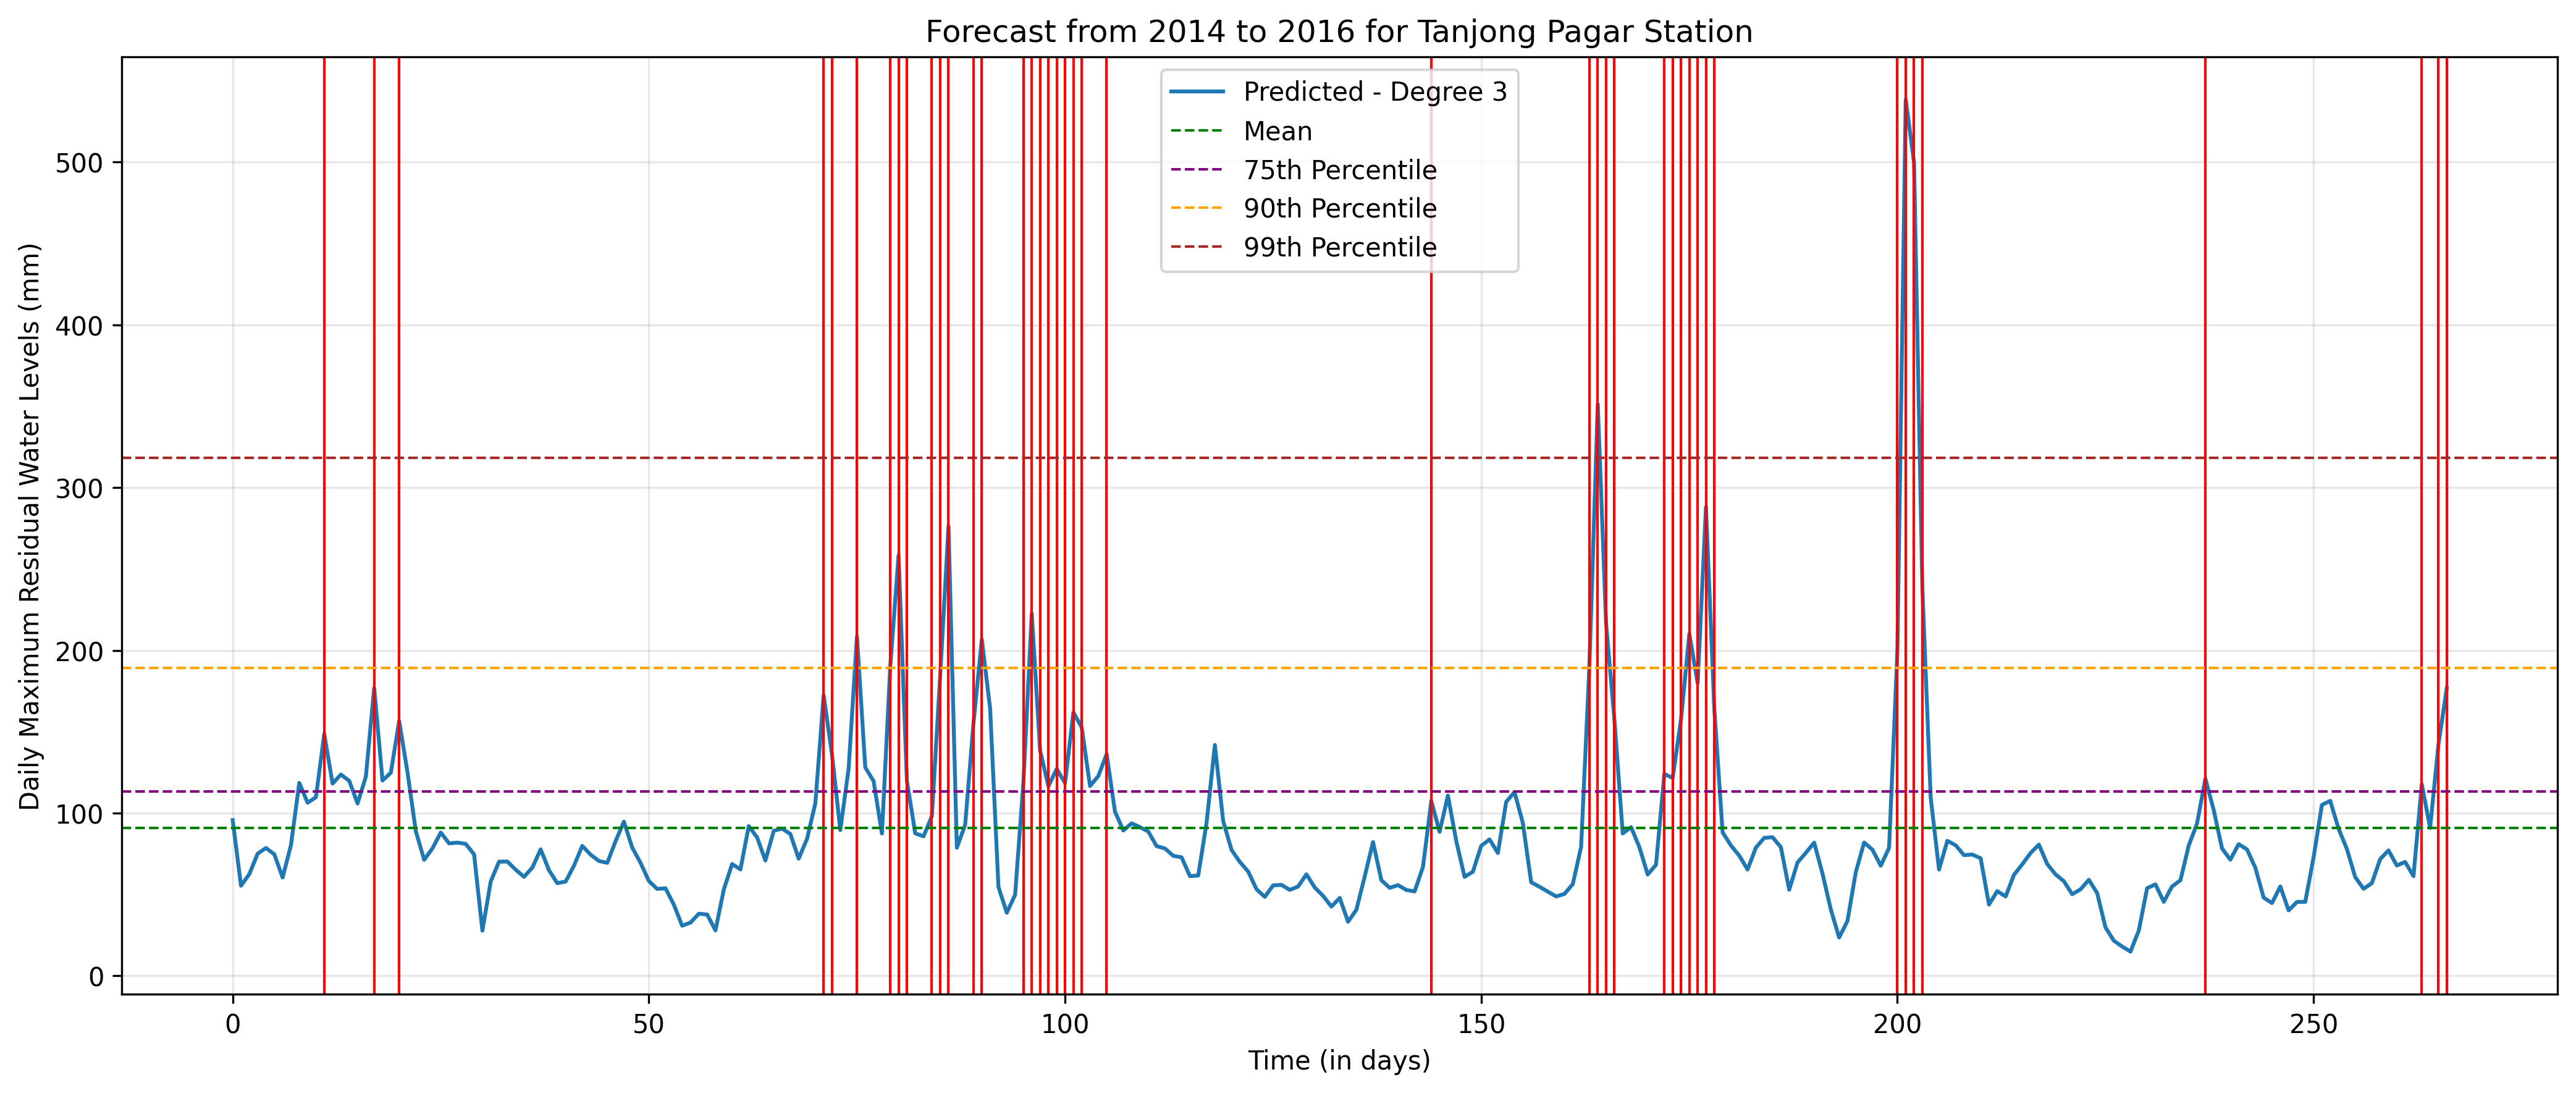

In [640]:
# Normalize to avoid KeyError on timestamps
index_dates = tp_residual_hindcast.index.normalize()
sd_dates = pd.to_datetime(sd_days_clean).normalize()
sd_day_indices = index_dates.get_indexer(sd_dates)
sd_day_indices = sd_day_indices[sd_day_indices != -1]

# Plot
plt.figure(figsize=(14, 6), dpi=300)
x = np.arange(len(tp_residual_hindcast))
y_obs = tp_residual_hindcast.values
y_pred = model3.predict(np.column_stack((wind_component_tp_norm_hindcast, msl_component_tp_norm_hindcast)))

plt.plot(x, y_pred, label="Predicted - Degree 3")

# Add surge lines
for idx in sd_day_indices:
    plt.axvline(x=idx, color='red', linewidth=1)
    
mean_val = y_pred.mean()
p75_val = np.percentile(y_obs, 75)
p90_val = np.percentile(y_obs, 90)
p99_val = np.percentile(y_obs, 99)

# Draw horizontal lines
plt.axhline(y=mean_val, color='green', linestyle='--', linewidth=1, label='Mean')
plt.axhline(y=p75_val, color='purple', linestyle='--', linewidth=1, label='75th Percentile')
plt.axhline(y=p90_val, color='orange', linestyle='--', linewidth=1, label='90th Percentile')
plt.axhline(y=p99_val, color='brown', linestyle='--', linewidth=1, label='99th Percentile')

plt.title("Forecast from 2014 to 2016 for Tanjong Pagar Station")
plt.xlabel("Time (in days)")
plt.ylabel("Daily Maximum Residual Water Levels (mm)")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


In [504]:
locations1

[{'name': 'Tioman', 'lat': 2.807, 'lon': 104.14},
 {'name': 'Kuantan', 'lat': 3.975, 'lon': 103.43},
 {'name': 'Cendering', 'lat': 5.265, 'lon': 103.187},
 {'name': 'Sedili', 'lat': 1.932, 'lon': 104.115},
 {'name': 'Johor Bahru', 'lat': 1.462, 'lon': 103.792},
 {'name': 'Geting', 'lat': 6.227, 'lon': 102.107},
 {'name': 'Tanjong Pagar', 'lat': 1.262, 'lon': 103.853}]

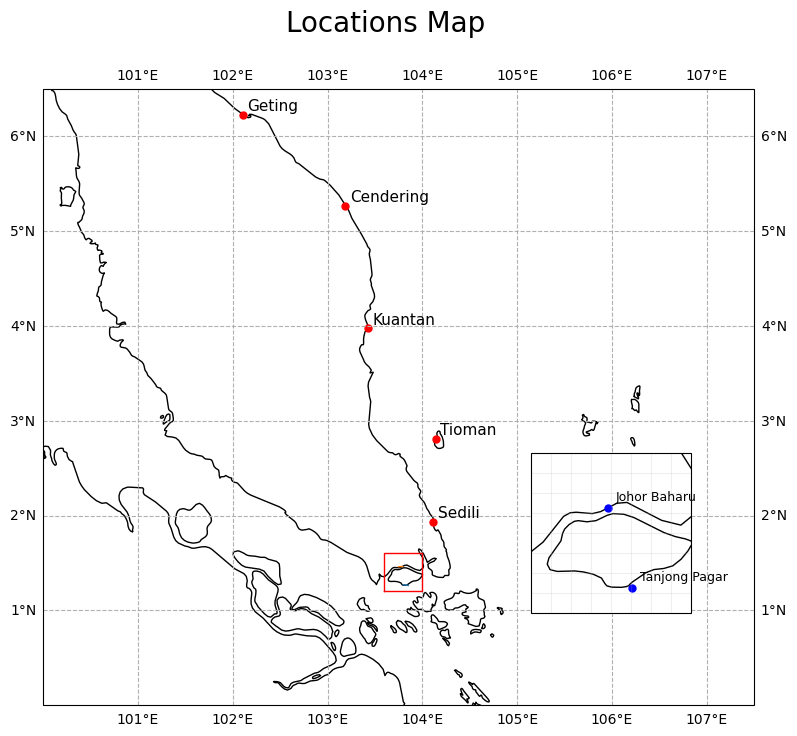

In [549]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Sample location data (replace with your actual data)
locations = {
    "Sedili": (104.115, 1.932),
    "Tioman": (104.14, 2.807),
    "Kuantan": (103.43, 3.975),
    "Cendering": (103.187, 5.265),
    "Geting": (102.107, 6.227), #added to plot the duplicate
}

locations_sg = {"Tanjong Pagar": (103.853, 1.262),
    "Johor Baharu": (103.792, 1.462),
}
# Load coastline data (replace with your actual shapefile or GeoJSON)
# For a quick example, using cartopy's built-in coastline feature:
coastline = cfeature.COASTLINE

# Create the map
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add coastlines
ax.add_feature(coastline)

# Plot locations
for name, (lon, lat) in locations.items():
    ax.plot(lon, lat, "ro", markersize=5)  # Plot red dots
    ax.text(lon + 0.05, lat + 0.05, name, fontsize=11)

# Set map extent (adjust as needed)
ax.set_extent([100, 107.5, 0, 6.5])

# Add gridlines (optional)
ax.gridlines(draw_labels=True, linestyle='--')

inset_ax = fig.add_axes([0.625, 0.225, 0.2, 0.2], projection=ccrs.PlateCarree())  # Adjust position and size7
inset_ax.add_feature(coastline)

# Plot inset locations
for name, (lon, lat) in locations_sg.items():
    inset_ax.plot(lon, lat, "bo", markersize=5)  # Blue dots for inset
    inset_ax.text(lon + 0.02, lat + 0.02, name, fontsize=9)

inset_ax.set_extent([103.6, 104, 1.2, 1.6])  # Zoom in on Johor Bahru/Tanjong Pagar
inset_ax.gridlines(alpha=0.2)

tp_lon, tp_lat = locations_sg["Tanjong Pagar"]
jb_lon, jb_lat = locations_sg["Johor Baharu"]

# Coordinates for the box in the main map
inset_extent = [103.6, 104, 1.2, 1.6]
inset_x1, inset_x2, inset_y1, inset_y2 = inset_extent

# Draw the connecting lines and the inset box
ax.plot([tp_lon, 103.8], [tp_lat, 1.27], transform=ccrs.PlateCarree(), linewidth=1)
ax.plot([jb_lon, 103.75], [jb_lat, 1.46], transform=ccrs.PlateCarree(), linewidth=1)

# Draw the box on the main map01
ax.plot([inset_x1, inset_x2, inset_x2, inset_x1, inset_x1],
        [inset_y1, inset_y1, inset_y2, inset_y2, inset_y1],
        color='red', transform=ccrs.PlateCarree(), linewidth=1)

plt.suptitle("Locations Map", fontsize=20)
plt.show()